In [6]:
# imports

import fitsio
import numpy as np
from datetime import datetime
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgb
from typing import Union, List, Dict

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import random_split, TensorDataset, DataLoader

CB_color_cycle = [
    '#377eb8', '#ff7f00', '#4daf4a',
    '#f781bf', '#a65628', '#984ea3',
    '#999999', '#e41a1c', '#dede00'
]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [7]:
def save_model_checkpoint(
    filepath: str,
    model: torch.nn.Module,
    optimizer: torch.optim.Optimizer = None,
    scheduler = None,
    epoch: int = 0,
    val_loss: float = float("inf"),
    config: dict = None
):
    """
    Saves a comprehensive PyTorch model checkpoint.
    """
    checkpoint = {
        "epoch": epoch,
        "val_loss": val_loss,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict() if optimizer else None,
        "scheduler_state_dict": scheduler.state_dict() if scheduler else None,
        "config": config or {}
    }
    torch.save(checkpoint, filepath)
    print(f"--> Saved checkpoint to '{filepath}' (Epoch {epoch+1}, Val Loss: {val_loss:.4f})")


def load_model_checkpoint(
    filepath: str,
    device: torch.device,
    model_class=None,
):
    """
    Loads a saved checkpoint and returns the model, optimizer/scheduler states, and metadata.
    """
    checkpoint = torch.load(filepath, map_location=device)
    config = checkpoint["config"]

    # Reconstruct model architecture using stored configuration
    model = model_class(
        in_channels=config.get("in_channels", 2),
        num_species=config.get("num_species", 1)
    ).to(device)

    # Load weights
    model.load_state_dict(checkpoint["model_state_dict"])
    
    print(f"--> Loaded checkpoint '{filepath}' (Trained for {checkpoint['epoch']+1} epochs, Val Loss: {checkpoint['val_loss']:.4f})")
    return model, checkpoint


In [8]:
# metal_dict = {'SiII_1190': 1190.4158, 'CIV_1548': 1548.2049, 'MgI_2853': 2852.96}

# 6.354e-4
# 1.487e-3
# 1e-4

In [9]:
#list of all metals in QQ

# metal_list = [
#     "MgI(2853)", "MgII(2804)", "MgII(2796)",
#     "FeII(2600)", "FeII(2587)", "MnII(2577)",
#     "FeII(2383)", "FeII(2374)", "FeII(2344)",
#     "AlIII(1863)", "AlIII(1855)", "AlII(1671)",
#     "FeII(1608)", "CIV(1551)", "CIV(1548)",
#     "SiII(1527)", "SiIV(1403)", "SiIV(1394)",
#     "CII(1335)", "SiII(1304)", "OI(1302)",
#     "SiII(1260)", "NV(1243)", "NV(1239)",
#     "SiIII(1207)", "NI(1200)", "SiII(1193)", "SiII(1190)",
#     "OI(1039)", "OVI(1038)", "OVI(1032)",
#     "LYB", "CIII(977)", "OI(989)", "SiII(990)",
#     "LY3", "LY4", "LY5",
# ]
# strength_list = [
#     "1e-4", "5e-4", "9e-4",          # MgI(2853) MgII(2804) MgII(2796)
#     "1e-4", "1e-4", "1e-4",          # FeII(2600) FeII(2587) MnII(2577)
#     "1e-4", "1e-4", "1e-4",          # FeII(2383) FeII(2374) FeII(2344)
#     "1e-4", "1e-4", "1e-4",          # AlIII(1863) AlIII(1855) AlII(1671)
#     "1e-4", "5.435e-4", "1.487e-3",  # FeII(1608) CIV(1551) CIV(1548)
#     "1e-4", "5e-4", "9e-4",          # SiII(1527) SiIV(1403) SiIV(1394)
#     "1e-4", "1e-4", "1e-4",          # CII(1335) SiII(1304) OI(1302)
#     "4.2504e-4", "5e-4", "5e-4",     # SiII(1260)* NV(1243) NV(1239)
#     "9.4595e-4", "1e-3", "6.354e-4", "4.496e-4",  # SiIII(1207)* NI(1200) SiII(1193)* SiII(1190)*
#     "1e-3", "3.382e-3", "5.358e-3",  # OI(1039) OVI(1038) OVI(1032)
#     "0.1901", "5e-3", "1e-3", "1e-3",# LYB CIII(977) OI(989) SiII(990)
#     "0.0697", "0.0335", "0.0187",    # LY3 LY4 LY5
# ]


# # Expected format: 
# METAL_LINES_LIST = {
#     "SiII_1190": 1190.4158,
#     "SiII_1193": 1193.2897,
#     "SiIII_1207": 1206.500,
#     "SiII_1260": 1206.500,
#     "CIV_1548": 1548.2049,
#     "CIV_1550": 1550.77845,
#     'MgI(2853)': 2852.96,
# }

### Check transmission file from P1D code

Wavelength shape: (31001,)
Single flux shape: (31001,)


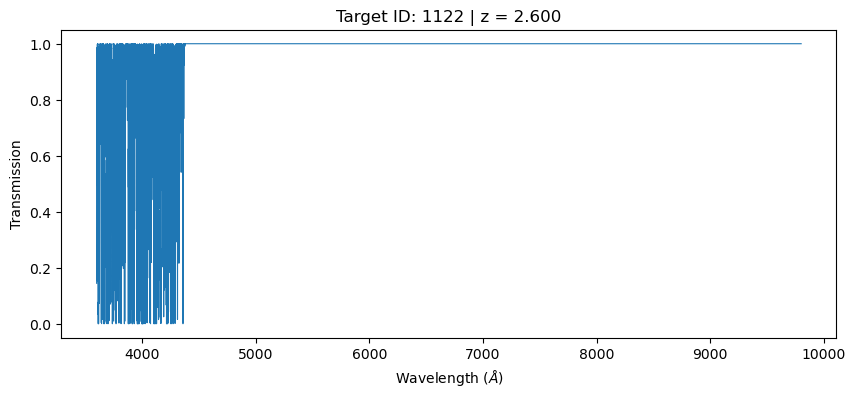

In [10]:
# load transmission file (preprocessed)
p1d_file = '/global/cfs/cdirs/desicollab/users/mherbold/p1d_mocks/DR1/QQ_output_test/transmission-16-1_2.fits'

# Read arrays
meta = fitsio.read(p1d_file, ext="METADATA")
wave = fitsio.read(p1d_file, ext="WAVELENGTH")
fluxes = fitsio.read(p1d_file, ext="TRANSMISSION")

# Pick single spectrum index
i = 100

# Extract and squeeze shape
single_flux = fluxes[i].squeeze()
target_id = meta["MOCKID"][i]
z = meta["Z"][i]

# Check shapes directly
print(f"Wavelength shape: {wave.shape}")        # Output: (31001,)
print(f"Single flux shape: {single_flux.shape}")  # Output: (31001,)

# Plot
plt.figure(figsize=(10, 4))
plt.plot(wave, single_flux, lw=0.8)
plt.xlabel(r"Wavelength ($\AA$)")
plt.ylabel("Transmission")
plt.title(f"Target ID: {target_id} | z = {z:.3f}")
# plt.xlim(3000,5000)
plt.show()

### Generate training samples

In [11]:
def convert_dataset_to_log_lambda(
    wave_grid: np.ndarray,
    fluxes: np.ndarray,
    num_log_wavelength_points: int = None
    ):
    """
    Convert a batch of transmission spectra from a linear wavelength grid
    to a uniformly spaced logarithmic wavelength grid.

    The input spectra are assumed to be transmission values sampled on a
    wavelength grid in Angstroms, with approximately uniform spacing
    (e.g. 0.2 Angstrom). The spectra are linearly interpolated onto a new
    grid that is uniformly spaced in ln(wavelength), such that the
    logarithmic wavelength separation is constant.

    Parameters
    ----------
    wave_grid : np.ndarray
        One-dimensional input wavelength grid in Angstroms. 

    fluxes : np.ndarray
        Array of transmission spectra sampled on ``wave_grid``, with shape
        ``(N_spectra, N_wavelengths)``. 

    num_log_wavelength_points : int, optional
        Number of wavelength samples in the output logarithmic wavelength
        grid. If ``None``, the output grid contains the same number of
        samples as the input grid.

    Returns
    -------
    log_wave_grid : np.ndarray
        One-dimensional uniformly spaced logarithmic wavelength grid,
        ``ln(lambda)``, with ``num_log_wavelength_points`` samples.

    fluxes_log : np.ndarray
        Array of transmission spectra interpolated onto ``log_wave_grid``,
        with shape ``(N_spectra, num_log_wavelength_points)``.
    """
    # Define uniform log-wavelength bounds
    log_wave_min = np.log(wave_grid[0])
    log_wave_max = np.log(wave_grid[-1])
    
    if num_log_wavelength_points is None:
        num_log_wavelength_points = len(wave_grid)
        
    log_wave_grid = np.linspace(log_wave_min, log_wave_max, num_log_wavelength_points)
    linear_wave_from_log = np.exp(log_wave_grid)
    
    # Re-interpolate all spectra onto the new uniform log wavelength grid
    N_specs = fluxes.shape[0]
    fluxes_log = np.zeros((N_specs, num_log_wavelength_points), dtype=np.float32)
    
    for idx in range(N_specs):
        fluxes_log[idx] = np.interp(linear_wave_from_log, wave_grid, fluxes[idx])
        
    return log_wave_grid, fluxes_log

Input X

├── channel 0: observed/noisy Lyα optical depth

├── channel 1: Lyα optical depth shifted to metal 1

├── channel 2: Lyα optical depth shifted to metal 2

└── ...


Targets Y

├── Y_mask: where each injected metal is present

            e.g.: Metal 1: [0 1 1 0 0 0 1 0 1]
            
            e.g.: Metal 2: [0 0 1 1 1 0 1 0 1]

└── Y_amp: log10(amplitude) of each injected metal

            e.g.: Metal 1: [0.2 0.21 0.09 0.008 0.1]
            
            e.g.: Metal 2: [0.1 0.11 0.03 0.01 0.08]


In [12]:
def generate_multimetal_dataset(
    lya_flux_samples: np.ndarray,
    log_wave_grid: np.ndarray,
    metal_dict: dict,
    lya_wave: float = 1215.67,
    num_samples: int = 5000,
    max_metals_per_spectrum: int = 1,
    snr: float = 30.0, # flux-space S/N; Gaussian noise has sigma = 1/snr
    tau_min_fraction: float = 0.0,
    tau_min_thresh = None,
    zero_metal_prob: float = 0.25,
    a_min = 0.2,
    a_max = 1.0,
) -> TensorDataset:

    """
    Generate a synthetic multi-metal mock dataset by injecting shifted copies of
    Lyα forest absorption into randomly selected Lyα spectra.

    The input Lyα spectra are converted from flux to optical depth,
    tau = -ln(F). For each injected metal species, the Lyα optical-depth
    field is shifted in log-wavelength according to the ratio of the metal
    rest-frame wavelength to the Lyα rest-frame wavelength, using continuous linear
    interpolation. The shifted optical depth is multiplied by a randomly
    drawn amplitude [a_min, a_max].

    Gaussian flux noise is optionally added according to the requested S/N, and
    the resulting noisy flux is converted back to optical depth. The input
    tensor contains the noisy Lyα optical depth (contaminated spectra) 
    together with one continuously shifted channel for /each/ metal species.

    Parameters
    ----------
    lya_flux_samples : np.ndarray
        Array of input Lyα forest flux spectra with shape 
        ``(n_input, n_wavelength_points)``. 

    log_wave_grid : np.ndarray
        One-dimensional logarithmically spaced wavelength grid with
        ``n_wavelength_points`` elements. 

    metal_dict : dict
        Dictionary mapping metal species names and rest-frame
        wavelengths in Angstroms. The order of the dictionary 
        determines the ordering of the metal channels and target arrays.
        For example::

            {'SiII_1190': 1190.4158,
                'MgI_2853': 2852.96,}

    lya_wave : float, optional
        Rest-frame wavelength of the Lyα transition in Angstroms.
        Default is 1215.67.

    num_samples : int, optional
        Number of synthetic spectra to generate. (Default is 5000.)

    max_metals_per_spectrum : int, optional
        Maximum number of different metal species that can be injected
        into a single spectrum. For each spectrum, between 1 and this
        value are selected randomly when metal contamination is injected.
        (Default is 1.)

    snr : float or None, optional
        Signal-to-noise ratio used to generate Gaussian flux noise.
        The noise standard deviation is ``1 / snr``. If ``None`` or
        ``snr >= 1e5``, no noise is added. (Default is 30.0.)

    tau_min_fraction : float, list, tuple, or dict, optional
        Minimum fractional optical-depth threshold used to define the
        target metal mask. When specified as a fraction, a wavelength_point is
        considered part of the metal line when::

            tau_metal_effective >= amplitude * tau_min_fraction

        This can be supplied as a scalar, a per-species list/tuple, or
        a dictionary keyed by species name. (Default is 0.0.)

    tau_min_thresh : float, list, tuple, or dict, optional
        Absolute effective optical-depth threshold used to define the
        target metal mask. If provided, this takes precedence over
        ``tau_min_fraction``. Can be supplied as a scalar, a per-species
        list/tuple, or a dictionary keyed by species name. (Default is None.)

    zero_metal_prob : float, optional
        Probability that a generated spectrum contains no metal
        contamination. (Default is 0.25.)

    a_min : float, list, tuple, or dict, optional
        Minimum metal absorption amplitude ``A``. The amplitude is sampled
        uniformly in log10 space between ``a_min`` and ``a_max``. Can be
        supplied as a scalar, a per-species list/tuple, or a dictionary
        keyed by species name. (Default is 0.2.)

    a_max : float, list, tuple, or dict, optional
        Maximum metal absorption amplitude ``A``. The amplitude is sampled
        uniformly in log10 space between ``a_min`` and ``a_max``. Can be
        supplied as a scalar, a per-species list/tuple, or a dictionary
        keyed by species name. (Default is 1.0.)

    Returns
    -------
    TensorDataset
        PyTorch ``TensorDataset`` containing three tensors:

        ``X_data`` : torch.Tensor
            Input features with shape
            ``(num_samples, 1 + num_species, n_wavelength_points)``.
            Channel 0 contains the noisy Lyα optical depth, while each
            subsequent channel contains a continuously shifted version of
            the noisy Lyα optical depth corresponding to one metal species.

        ``Y_mask`` : torch.Tensor
            Binary target metal masks with shape
            ``(num_samples, num_species, n_wavelength_points)``. A value of 1
            identifies wavelength_points where the injected effective metal optical
            depth exceeds the specified threshold.

        ``Y_amp`` : torch.Tensor
            Metal amplitude targets with shape
            ``(num_samples, num_species, n_wavelength_points)``. Wavelength_points belonging
            to an injected metal line contain the log10 amplitude,
            ``log10(A)``. Wavelength_points without an injected metal are assigned
            ``-10``.
    """
    
    n_input, n_wavelength_points = lya_flux_samples.shape
    num_species = len(metal_dict)
    species_keys = list(metal_dict.keys())
    
    # Precompute exact continuous logarithmic offsets: Delta log(lambda) = log(lambda_metal / lambda_lya)
    # Detect grid base automatically (natural log vs log10) based on log_wave_grid span
    is_log10 = (log_wave_grid[-1] - log_wave_grid[0]) < 2.0
    if is_log10:
        log_offsets = {key: np.log10(w / lya_wave) for key, w in metal_dict.items()}
    else:
        log_offsets = {key: np.log(w / lya_wave) for key, w in metal_dict.items()}

    X_data = np.zeros(
        (num_samples, 1 + num_species, n_wavelength_points), 
        dtype=np.float32)
    Y_mask = np.zeros(
        (num_samples, num_species, n_wavelength_points), 
        dtype=np.float32)
    Y_amp  = np.full(
        (num_samples, num_species, n_wavelength_points), -10.0, 
        dtype=np.float32)

    tau_lya_pool = -np.log(np.clip(lya_flux_samples, 1e-4, 1.0))

    for i in range(num_samples):
        rand_idx = np.random.randint(0, n_input)
        tau_lya = tau_lya_pool[rand_idx]
        tau_total = np.copy(tau_lya)
        
        inject_metal = (np.random.rand() > zero_metal_prob)

        if inject_metal:
            n_active = np.random.randint(1, max_metals_per_spectrum + 1)
            active_species = np.random.choice(species_keys, 
                                              size=n_active, 
                                              replace=False)

            for species in active_species:
                s_idx = species_keys.index(species)
                delta_log_w = log_offsets[species]
                
                # Resolve per-species hyperparameters
                sp_a_min = a_min.get(species, 0.2) if isinstance(a_min, dict) else (a_min[s_idx] if isinstance(a_min, (list, tuple)) else float(a_min))
                sp_a_max = a_max.get(species, 1.0) if isinstance(a_max, dict) else (a_max[s_idx] if isinstance(a_max, (list, tuple)) else float(a_max))
                sp_tau_frac = tau_min_fraction.get(species, 0.05) if isinstance(tau_min_fraction, dict) else (tau_min_fraction[s_idx] if isinstance(tau_min_fraction, (list, tuple)) else float(tau_min_fraction))

                log_a_min, log_a_max = np.log10(sp_a_min), np.log10(sp_a_max)
                log10_A = np.random.uniform(log_a_min, log_a_max) if log_a_min != log_a_max else log_a_min
                A = 10.0 ** log10_A

                # Continuous shift via linear interpolation (filling padded edges with 0.0 optical depth)
                tau_metal = np.interp(
                    log_wave_grid - delta_log_w,
                    log_wave_grid,
                    tau_lya,
                    left=0.0,
                    right=0.0
                )
                
                tau_metal_effective = A * tau_metal
                tau_total += tau_metal_effective
                
                # Resolve active line mask
                if tau_min_thresh is not None:
                    sp_tau_thresh = tau_min_thresh.get(species, 0.05) if isinstance(tau_min_thresh, dict) else (tau_min_thresh[s_idx] if isinstance(tau_min_thresh, (list, tuple)) else float(tau_min_thresh))
                    metal_active_mask = (tau_metal_effective >= sp_tau_thresh)
                else:
                    # metal_active_mask = (tau_metal >= sp_tau_frac)
                    metal_active_mask = (tau_metal_effective >= (A * sp_tau_frac))

                Y_mask[i, s_idx, :] = metal_active_mask.astype(np.float32)
                Y_amp[i, s_idx, :]  = log10_A

        # Flux conversion & noise injection
        flux_true = np.exp(-tau_total)
        if snr is None or snr >= 1e5:
            flux_obs = flux_true
        else:
            noise = np.random.normal(0.0, 1.0 / snr, size=n_wavelength_points)
            flux_obs = np.clip(flux_true + noise, 1e-4, 1.5)
            
        tau_obs = -np.log(np.clip(flux_obs, 1e-4, 1.0))

        # Fill input tensor channels using continuous shift interpolation
        X_data[i, 0, :] = tau_obs
        for s_idx, species in enumerate(species_keys):
            delta_log_w = log_offsets[species]
            X_data[i, 1 + s_idx, :] = np.interp(
                log_wave_grid - delta_log_w,
                log_wave_grid,
                tau_obs,
                left=0.0,
                right=0.0
            )

    return TensorDataset(
        torch.from_numpy(X_data),
        torch.from_numpy(Y_mask),
        torch.from_numpy(Y_amp)
    )

In [13]:
# 0. Resample wavelength AND fluxes to uniform log space
log_wave, fluxes_log = convert_dataset_to_log_lambda(wave, fluxes)

# 1. Configuration
lya_wave = 1215.67
metal_dict = {'SiII_1190': 1190.4158, 'CIV_1548': 1548.2049, 'MgI_2853': 2852.96}
# a_target = [0.0002, 0.0005, 0.0001]

a_target = [
    6.354e-4,
    1.487e-3,
    1e-4,
    ]

max_metals_per_spectrum = 3
tau_min_fraction = 0.05
zero_metal_prob = 0.10

# set min detectable optical depth per metal species
tau_core_cutoff = 1.0
tau_min_thresh = [a * tau_core_cutoff for a in a_target] 

# 2. Training Dataset
dataset = generate_multimetal_dataset(
    lya_flux_samples=fluxes_log,
    log_wave_grid=log_wave,
    metal_dict=metal_dict,
    a_min=a_target, 
    a_max=a_target,
    num_samples=10000,
    max_metals_per_spectrum=max_metals_per_spectrum,
    snr=None,
    # tau_min_fraction=tau_min_fraction,
    tau_min_thresh=tau_min_thresh,
    zero_metal_prob=zero_metal_prob,
)

# 3. Create DataLoader (Yields: X, y_mask, y_amp)
batch_size = 32

data_loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

In [8]:
def plot_example_training_samples(
    dataset, 
    metal_dict: dict, 
    log_wave_grid: np.ndarray = None, 
    num_samples: int = 3,
    zoom_margin_wavelength_points: int = 250,
):
    """
    Plots example samples from the multi-metal dataset for visual inspection.
    Converts tau_obs back to normalized flux (F = exp(-tau)) and overlays ground truth masks.
    """
    species_names = list(metal_dict.keys())
    num_species = len(species_names)
    
    # Palette for highlighting active metal masks
    palette = plt.cm.get_cmap("Set1", max(8, num_species))
    
    # Randomly pick sample indices
    indices = np.random.choice(len(dataset), size=num_samples, replace=False)
    
    # Establish X-axis (Wavelength vs. wavelength_point Index)
    if log_wave_grid is not None:
        # Auto-detect if log_wave_grid is natural log, log10, or already lambda
        if np.max(log_wave_grid) > 100:
            wave_axis = log_wave_grid
        elif np.max(log_wave_grid) < 5:  # log10 space (~3.1 to 3.5 for optical/UV)
            wave_axis = 10.0 ** log_wave_grid
        else:  # natural log space (~7.1 to 8.1)
            wave_axis = np.exp(log_wave_grid)
        x_label = r"Wavelength ($\AA$)"
    else:
        wave_axis = np.arange(dataset[0][0].shape[-1])
        x_label = "Wavelength_point Index"

    fig, axes = plt.subplots(num_samples, 1, figsize=(14, 3.5 * num_samples), sharex=False)
    if num_samples == 1:
        axes = [axes]

    for i, idx in enumerate(indices):
        ax = axes[i]
        
        # Unpack tensors
        X, Y_mask, Y_amp = dataset[idx]
        tau_obs = X[0].numpy()
        flux_obs = np.exp(-tau_obs)  # Convert optical depth to flux space
        masks = Y_mask.numpy()
        amps = Y_amp.numpy()
        
        # Plot normalized flux
        ax.plot(wave_axis, flux_obs, color="black", lw=0.7, alpha=0.8, label=r"Observed Flux ($e^{-\tau}$)")
        ax.axhline(1.0, color="gray", linestyle="--", lw=1, alpha=0.5)
        
        # Overlay injected species masks
        injected_info = []
        active_wavelength_point_indices = []

        for s_idx, s_name in enumerate(species_names):
            mask_s = masks[s_idx] > 0.5
            if np.any(mask_s):
                color = palette(s_idx)
                
                # Get linear amplitude A = 10^(log10_A)
                amp_val = 10.0 ** np.median(amps[s_idx, mask_s])
                injected_info.append(f"{s_name} (A={amp_val:.3f})")
                
                # Store active indices to handle optional zoom cropping
                active_wavelength_point_indices.extend(np.where(mask_s)[0])
                
                # Fill region under active line mask
                ax.fill_between(
                    wave_axis, 
                    0, 
                    1.2, 
                    where=mask_s, 
                    color=color, 
                    alpha=0.35, 
                    label=f"Mask: {s_name}"
                )

        # Set title and labels
        title_str = f"Sample #{idx} | " + (f"Injected: {', '.join(injected_info)}" if injected_info else "Pure Lya Forest (No Metals)")
        ax.set_title(title_str, fontsize=11, fontweight="bold")
        ax.set_ylabel("Normalized Flux")
        ax.set_ylim(-0.05, 1.25)
        ax.grid(True, alpha=0.25)
        ax.legend(loc="lower left", fontsize=9, framealpha=0.9)
        ax.set_xlabel(x_label)

        # Zoom into active metal region if present
        if len(active_wavelength_point_indices) > 0 and zoom_margin_wavelength_points is not None:
            min_pix = max(0, np.min(active_wavelength_point_indices) - zoom_margin_wavelength_points)
            max_pix = min(len(wave_axis) - 1, np.max(active_wavelength_point_indices) + zoom_margin_wavelength_points)
            ax.set_xlim(wave_axis[min_pix], wave_axis[max_pix])

    plt.tight_layout()
    plt.show()

/tmp/ipykernel_1222045/3039352663.py:16: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  palette = plt.cm.get_cmap("Set1", max(8, num_species))


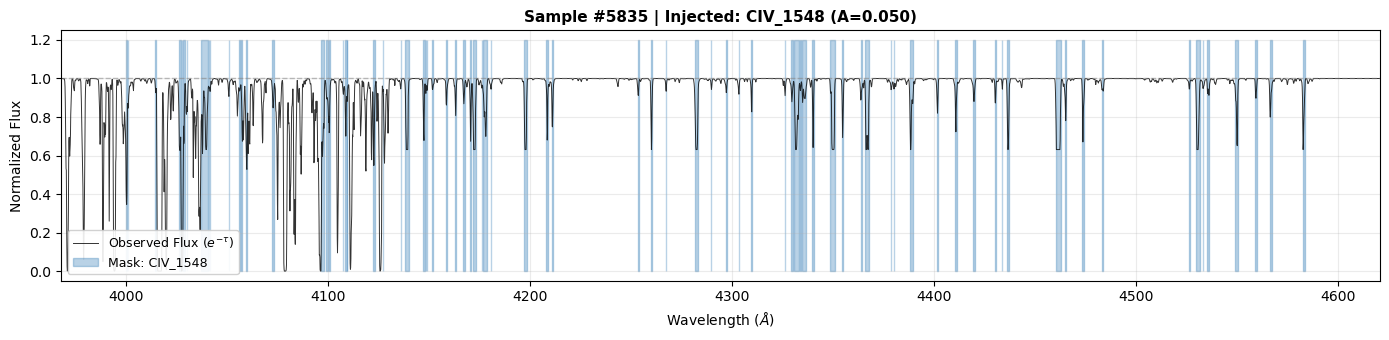

In [19]:
# plot example training data
plot_example_training_samples(
    dataset, 
    metal_dict = metal_dict,
    log_wave_grid = log_wave, 
    num_samples = 1,
)

## Setting up the CNN Architecture

**(Architecture overview)**

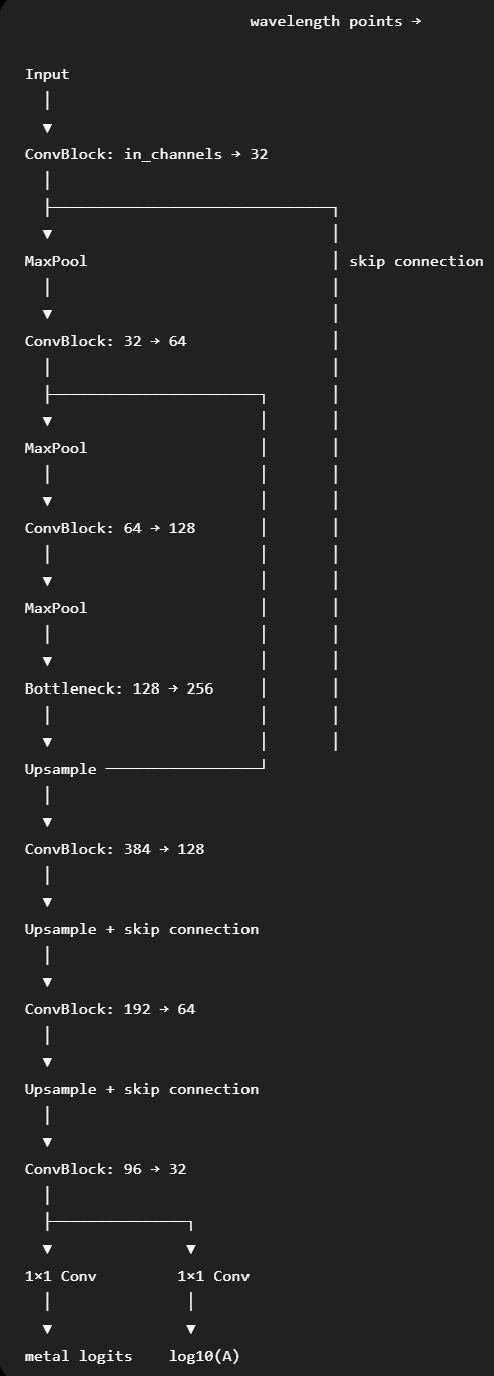

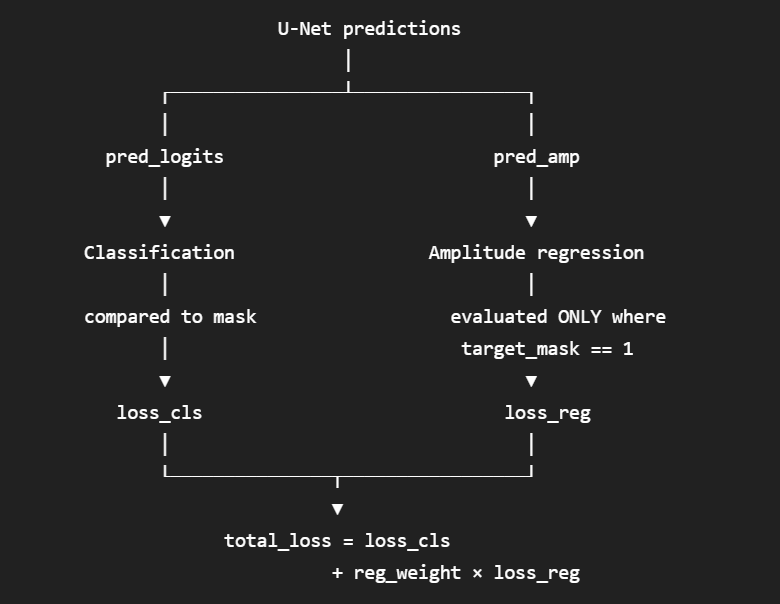

In [14]:
class ConvBlock1D(nn.Module):
    """
    Two-layer 1D convolutional block used throughout the U-Net.

    Each convolution has: kernel size 5 + padding, batch 
    normalization, ReLU activation. 

    Notes
    -----
    The convolution operates along the wavelength axis while combining
    information across the input feature channels. Because the convolutions
    use ``padding=2`` with ``kernel_size=5``, the number of wavelength points
    is unchanged by the block.
    """
    def __init__(self, in_ch: int, out_ch: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(in_ch, out_ch, kernel_size=5, padding=2),
            nn.BatchNorm1d(out_ch),
            nn.ReLU(),
            nn.Conv1d(out_ch, out_ch, kernel_size=5, padding=2),
            nn.BatchNorm1d(out_ch),
            nn.ReLU()
        )
    def forward(self, x):
        return self.net(x)


class SpectralUNet1D(nn.Module):
    """
    1D U-Net for identifying and characterizing metal absorption features
    along a logarithmic wavelength grid.

    The network takes a set of spectral feature channels (with / without 
    metal contamination) defined at each wavelength point and processes 
    them through an encoder-decoder architecture.

    Encoder: progressively downsamples the wavelength dimension while
             increasing the number of feature channels, allowing the 
             network to learn increasingly broad spectral context. 
    
    Decoder: progressively restores the original wavelength resolution. 
    
    Skip connections: connect encoder and decoder layers at matching 
                      resolutions, allowing fine-scale spectral 
                      information to be retained.

    The network has two output heads:

    * Classification: predicts a metal-detection logit for each
                      metal species at each wavelength point.
    * Regression: predicts the log10 metal absorption amplitude,
                  log10(A), for each metal species at each wavelength point.

    Parameters
    ----------
    in_channels : int
        Number of input spectral feature channels. For the multi-metal
        dataset, this is ``1 + num_species``: one channel containing the
        observed Lyα optical depth and one shifted channel per metal species.

    num_species : int
        Number of metal species being modeled. This determines the number
        of output channels in both the classification and regression heads.

    Input
    -----
    x : torch.Tensor
        Input tensor with shape
        ``(batch_size, in_channels, n_wavelength_points)``.

    Returns
    -------
    mask_logits : torch.Tensor
        Classification logits with shape
        ``(batch_size, num_species, n_wavelength_points)``.
        Each output channel corresponds to ONE metal species. The logits
        can be converted to detection probabilities using a sigmoid:

        ``probability = sigmoid(mask_logits)``

    amp_pred : torch.Tensor
        Predicted log10 metal absorption amplitudes with shape
        ``(batch_size, num_species, n_wavelength_points)``.
        The regression output is not passed through an activation function,
        allowing the network to predict a continuous range of amplitudes.

    Notes
    -----
    Max pooling reduces the number of wavelength points by a factor of two
    at each encoder level. The decoder uses linear interpolation to restore
    the wavelength dimension to the resolution of the corresponding encoder
    layer before applying the convolutional block.

    The three encoder levels therefore provide progressively larger
    spectral receptive fields, while the skip connections preserve
    wavelength-local information needed for locating individual absorption
    features.
    """
    def __init__(self, in_channels: int, num_species: int):
        super().__init__()
        # Encoder
        self.enc1 = ConvBlock1D(in_channels, 32)
        self.pool1 = nn.MaxPool1d(2)
        self.enc2 = ConvBlock1D(32, 64)
        self.pool2 = nn.MaxPool1d(2)
        self.enc3 = ConvBlock1D(64, 128)
        self.pool3 = nn.MaxPool1d(2)
        
        # Bottleneck
        self.bottleneck = ConvBlock1D(128, 256)
        
        # Decoder
        self.dec3 = ConvBlock1D(256 + 128, 128)
        self.dec2 = ConvBlock1D(128 + 64, 64)
        self.dec1 = ConvBlock1D(64 + 32, 32)
        
        # Output Heads (1D convolutions with 1x1 kernel)
        self.cls_head = nn.Conv1d(32, num_species, kernel_size=1) # Logits
        self.reg_head = nn.Conv1d(32, num_species, kernel_size=1) # Amplitude log10(A)

    def forward(self, x):
        # Encoder
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool1(e1))
        e3 = self.enc3(self.pool2(e2))
        
        # Bottleneck
        b = self.bottleneck(self.pool3(e3))
        
        # Decoder with length-matched upsampling
        d3 = F.interpolate(b, size=e3.shape[-1], mode='linear', align_corners=False)
        d3 = self.dec3(torch.cat([d3, e3], dim=1))
        
        d2 = F.interpolate(d3, size=e2.shape[-1], mode='linear', align_corners=False)
        d2 = self.dec2(torch.cat([d2, e2], dim=1))
        
        d1 = F.interpolate(d2, size=e1.shape[-1], mode='linear', align_corners=False)
        d1 = self.dec1(torch.cat([d1, e1], dim=1))
        
        # Heads
        mask_logits = self.cls_head(d1)
        amp_pred = self.reg_head(d1)
        
        return mask_logits, amp_pred

In [15]:
class CalibratedMultiMetalLoss(nn.Module):
    """
    Combined classification and amplitude-regression loss for the
    multi-metal spectral U-Net.

    The loss has two components:

    1. Classification loss
       Binary cross-entropy with logits is used to predict whether each
       wavelength point contains absorption from each metal species.

       Psitive examples are weighted using a species-dependent
       ``pos_weight``. The weight is determined from the metal's
       log-wavelength distance from Lyα, such that metal species closer 
       to Lyα receive a larger positive weight, while species farther from Lyα
       approach ``base_pos_weight``.

    2. Amplitude regression loss
       A Smooth L1 loss is used to predict the metal absorption amplitude
       ``log10(A)``. This loss is evaluated only at wavelength points that
       are marked as active in the ground-truth metal mask. Thus, the
       amplitude prediction is trained /only/ where a metal is actually
       present.

    Total loss = loss_cls + reg_weight * loss_reg

    Parameters
    ----------
    metal_dict : dict
        Dictionary mapping metal species names to their rest-frame
        wavelengths in Angstroms. The dictionary order /must/ match the
        species/channel ordering used by the model outputs and target
        tensors.

    lya_wave : float, optional
        Rest-frame wavelength of the Lyα transition in Angstroms.
        Default is 1215.67.

    base_pos_weight : float, optional
        Minimum classification ``pos_weight`` assigned to metal species
        that are far from Lyα in log-wavelength space. Default is 1.0.

    max_pos_weight : float, optional
        Maximum classification ``pos_weight`` assigned to metal species
        located very close to Lyα in log-wavelength space. Default is 2.5.

    decay_scale : float, optional
        Characteristic log-wavelength distance over which the
        species-dependent positive classification weight decreases from
        ``max_pos_weight`` toward ``base_pos_weight``. Default is 0.25.

    reg_weight : float, optional
        Relative weight applied to the amplitude regression loss when
        combining it with the classification loss. Default is 1.0.

    Notes
    -----
    The classification weights are calculated once when the loss object
    is initialized and stored as a tensor with shape
    ``(1, num_species, 1)``. This allows the weights to broadcast across
    both the batch and wavelength-point dimensions of the model outputs.

    The classification ``pos_weight`` does not change during training.

    The amplitude regression loss uses the ground-truth mask rather than
    the model's predicted mask. Therefore, amplitude predictions are
    supervised only at wavelength points known to contain the corresponding
    metal in the training target.

    If a training batch contains no active metal wavelength points, the
    regression contribution is set to zero for that batch.
    """    
    def __init__(
        self, 
        metal_dict: dict, 
        lya_wave: float = 1215.67, 
        base_pos_weight: float = 1.0, 
        max_pos_weight: float = 2.5, 
        decay_scale: float = 0.25, 
        reg_weight: float = 1.0
    ):        
        super().__init__()
        self.reg_weight = reg_weight
        
        # Calculate species-dependent classification weights.
        #
        # Metals closer to Lyα in log-wavelength space receive a larger
        # positive weight. This compensates for the greater similarity
        # between their shifted Lyα input channels and the observed Lyα
        # absorption.
        
        weights = []
        
        print("----------------------------------------------------")
        print("--- Automatic Per-Species Classification Weights ---")
        
        for species, w_metal in metal_dict.items():
            
            # Distance in log-wavelength space
            log_dist = abs(np.log(w_metal / lya_wave))
            
            # Exponential decay mapping distance to pos_weight
            weight = base_pos_weight + (max_pos_weight - base_pos_weight) * np.exp(-log_dist / decay_scale)
            weights.append(weight)
            
            print(
                f"  {species:12s} | "
                f"lambda = {w_metal:8.2f} A | "
                f"dist = {log_dist:.4f} | "
                f"pos_weight = {weight:.3f}"     
            )
                
        print("----------------------------------------------------\n")

        # Shape: [1, num_species, 1]
        # This broadcasts naturally against model outputs with shape:
        # [batch_size, num_species, n_wavelength_points]
        pos_weight_tensor = torch.tensor(
            weights,
            dtype=torch.float32
        ).view(1, -1, 1)

        # Register as a buffer so that the tensor automatically moves
        # with the model/loss object between CPU and GPU.
        self.register_buffer("pos_weight", pos_weight_tensor)
        
    def forward(self, pred_logits, pred_amp, target_mask, target_amp):
        """
        Calculate the combined classification and amplitude-regression loss.

        Parameters
        ----------
        pred_logits : torch.Tensor
            Classification logits predicted by the U-Net, with shape
            ``(batch_size, num_species, n_wavelength_points)``.
            Applying a sigmoid converts these logits into metal detection
            probabilities.

        pred_amp : torch.Tensor
            Predicted log10 metal absorption amplitudes, with shape
            ``(batch_size, num_species, n_wavelength_points)``.

        target_mask : torch.Tensor
            Binary ground-truth metal mask with shape
            ``(batch_size, num_species, n_wavelength_points)``.
            A value of 1 indicates an active wavelength point belonging
            to the corresponding metal species.

        target_amp : torch.Tensor
            Ground-truth log10 metal absorption amplitudes with shape
            ``(batch_size, num_species, n_wavelength_points)``.
            Values at active wavelength points contain the injected
            ``log10(A)`` value.

        Returns
        -------
        total_loss : torch.Tensor
            Combined classification and amplitude-regression loss.

        loss_cls : torch.Tensor
            Binary cross-entropy classification loss with the
            species-dependent positive weights.

        loss_reg : torch.Tensor
            Smooth L1 amplitude-regression loss evaluated only at
            ground-truth active wavelength points.
        """
        # 1. Classification Loss with [1, num_species, 1] broadcasting
        loss_cls = F.binary_cross_entropy_with_logits(
            pred_logits, 
            target_mask, 
            pos_weight=self.pos_weight.to(pred_logits.device)
        )
        
        # 2. Masked Amplitude Regression Loss on Active wavelength_points Only
            # Only train the amplitude prediction where the ground-truth
            # target identifies an active metal wavelength point.
        active_mask = target_mask > 0.5
        num_positives = active_mask.sum()

        # Note: supervised training, uses knowledge of ground-truth
        if num_positives > 0:
            # Smooth L1 loss is calculated only over ground-truth
            # active wavelength points.
            loss_reg = F.smooth_l1_loss(
                pred_amp[active_mask], 
                target_amp[active_mask], 
                reduction='mean'
            )
        else:
            # No active metal points are present in this batch, so there
            # is no amplitude information on which to calculate a loss.
            loss_reg = torch.tensor(0.0, device=pred_logits.device)

        # 3. Combine classification and regression losses
        total_loss = loss_cls + self.reg_weight * loss_reg
        return total_loss, loss_cls, loss_reg
        

In [16]:
class DilatedBlock1D(nn.Module):
    """
    Residual 1D convolutional block with progressively increasing dilation.

    This block applies three 1D convolutions with dilation factors of 1, 2,
    and 4. Increasing the dilation factor expands the receptive field without
    increasing the number of convolutional kernel elements or changing the
    number of wavelength points in the output.

    Each convolution is followed by batch normalization and ReLU activation.
    A residual shortcut connects the input directly to the output. If the
    input and output channel counts differ, a 1x1 convolution is used to
    match the number of channels before the residual addition.

    Parameters
    ----------
    in_ch : int
        Number of input feature channels.
    out_ch : int
        Number of output feature channels.

    Notes
    -----
    The convolutions operate along the wavelength-point dimension. The
    padding values are chosen so that each convolution preserves the number
    of wavelength points.

    The progressively larger dilation factors allow the block to combine
    information over multiple spectral scales, which can be useful when
    distinguishing metal absorption profiles from broader or more complex
    structure in the Lyα forest.
    """
    def __init__(self, in_ch: int, out_ch: int):
        super().__init__()

        # Standard convolution: local spectral information.
        self.conv1 = nn.Conv1d(
            in_ch, out_ch, kernel_size=3, padding=1, dilation=1
        )
        self.bn1 = nn.BatchNorm1d(out_ch)

        # Dilated convolution: larger receptive field.
        self.conv2 = nn.Conv1d(
            out_ch, out_ch, kernel_size=3, padding=2, dilation=2
        )
        self.bn2 = nn.BatchNorm1d(out_ch)

        # More strongly dilated convolution: still larger receptive field.
        self.conv3 = nn.Conv1d(
            out_ch, out_ch, kernel_size=3, padding=4, dilation=4
        )
        self.bn3 = nn.BatchNorm1d(out_ch)

        # Residual connection. A 1x1 convolution is needed when the
        # number of input and output feature channels differs.
        self.shortcut = (
            nn.Conv1d(in_ch, out_ch, kernel_size=1)
            if in_ch != out_ch
            else nn.Identity()
        )
        
    def forward(self, x):
        # Preserve the input for the residual connection.
        res = self.shortcut(x)

        # Apply progressively more dilated convolutions.
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = F.relu(self.bn3(self.conv3(x)))

        # Add the residual connection and apply the final activation.
        return F.relu(x + res)


class SpectralDilatedUNet1D(nn.Module):
    """
    1D U-Net with residual dilated convolutional blocks.

    This architecture is an alternative to ``SpectralUNet1D`` in which each
    convolutional block uses progressively dilated convolutions and a
    residual shortcut. The dilated convolutions increase the receptive field
    along the wavelength dimension while retaining the same number of
    wavelength points within each block.

    Encoder: progressively downsamples the wavelength dimension while
             increasing the number of feature channels. 
    Bottleneck: provides the deepest representation of the spectrum. 
    Decoder: restores the original wavelength-point resolution. 
    Skip connections: preserve information from earlier encoder stages.

    Two output heads are used:

    * ``cls_head`` predicts a classification logit for each metal species at
                   every wavelength point. Applying ``sigmoid`` converts 
                   these logits into detection probabilities.
    * ``reg_head`` predicts the metal absorption amplitude, represented as
                  ``log10(A)``, for each metal species at every wavelength point.

    Parameters
    ----------
    in_channels : int
        Number of input feature channels. For the multi-metal dataset this is
        typically ``1 + num_species``.
    num_species : int
        Number of metal species being detected and characterized.

    Input
    -----
    x : torch.Tensor
        Input tensor with shape
        ``(batch_size, in_channels, n_wavelength_points)``.

    Returns
    -------
    mask_logits : torch.Tensor
        Classification logits with shape
        ``(batch_size, num_species, n_wavelength_points)``.
    amp_pred : torch.Tensor
        Predicted ``log10(A)`` values with shape
        ``(batch_size, num_species, n_wavelength_points)``.

    Notes
    -----
    Max pooling reduces the wavelength-point resolution by a factor of two
    at each encoder level. The decoder uses linear interpolation to restore
    the wavelength-point resolution before combining each decoder feature
    map with its corresponding encoder output.

    The 1x1 output convolutions operate independently at each wavelength
    point, mapping the final 32 feature channels to one output per metal
    species. The preceding convolutional blocks provide the spectral
    context used to make these predictions.
    """    
    def __init__(self, in_channels: int, num_species: int):
        super().__init__()
        # Encoder
        self.enc1 = DilatedBlock1D(in_channels, 32)
        self.pool1 = nn.MaxPool1d(2)
        self.enc2 = DilatedBlock1D(32, 64)
        self.pool2 = nn.MaxPool1d(2)
        self.enc3 = DilatedBlock1D(64, 128)
        self.pool3 = nn.MaxPool1d(2)
        
        # Bottleneck
        self.bottleneck = DilatedBlock1D(128, 256)
        
        # Decoder
        self.dec3 = DilatedBlock1D(256 + 128, 128)
        self.dec2 = DilatedBlock1D(128 + 64, 64)
        self.dec1 = DilatedBlock1D(64 + 32, 32)
        
        # Output Heads
        # One output channel is produced for each metal species.
        self.cls_head = nn.Conv1d(32, num_species, kernel_size=1)
        self.reg_head = nn.Conv1d(32, num_species, kernel_size=1)

    def forward(self, x):
        # Encoder
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool1(e1))
        e3 = self.enc3(self.pool2(e2))

        # Bottleneck
        b = self.bottleneck(self.pool3(e3))

        # Decoder
        d3 = F.interpolate(b, size=e3.shape[-1], mode='linear', align_corners=False)
        d3 = self.dec3(torch.cat([d3, e3], dim=1))
        
        d2 = F.interpolate(d3, size=e2.shape[-1], mode='linear', align_corners=False)
        d2 = self.dec2(torch.cat([d2, e2], dim=1))
        
        d1 = F.interpolate(d2, size=e1.shape[-1], mode='linear', align_corners=False)
        d1 = self.dec1(torch.cat([d1, e1], dim=1))

        # output heads
        mask_logits = self.cls_head(d1)
        amp_pred = self.reg_head(d1)
        
        return mask_logits, amp_pred

In [17]:
epochs = 10

In [18]:
# 1. Train/Validation Split (80/20)
# ----------------------------------
generator = torch.Generator().manual_seed(42) # optional seed

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_set, val_set = random_split(
    dataset, [train_size, val_size], 
    generator=generator) # optional seed

train_loader = DataLoader(
    train_set, 
    batch_size=16, 
    shuffle=True) # Reduced batch size to 16 for memory
val_loader = DataLoader(
    val_set, 
    batch_size=16, 
    shuffle=False)


# 2. Channels
# ----------------------------------
# Number of input feature channels:
#   channel 0 = Lyα optical depth
#   channels 1...N = shifted optical-depth channels for each metal species
num_channels = dataset[0][0].shape[0]

# Number of metal species predicted by the two output heads.
num_species = dataset[0][1].shape[0]

In [19]:
# 3. Model
# ----------------------------------
# SpectralUNet1D uses standard convolutional blocks.
# SpectralDilatedUNet1D uses dilated residual blocks with a larger
# receptive field along the wavelength dimension.

# model = SpectralUNet1D(
#     in_channels=num_channels,
#     num_species=num_species
# ).to(device)

model = SpectralDilatedUNet1D(
    in_channels=num_channels,
    num_species=num_species
).to(device)

In [20]:
# 4. Loss, optimizer
# ----------------------------------
# Species-dependent positive-class weighting for the classification loss.
# Lines closer to Lyα receive greater weight.
criterion = CalibratedMultiMetalLoss(
    metal_dict=metal_dict,
    lya_wave=lya_wave,
    base_pos_weight=1.0,
    max_pos_weight=2.5,
    decay_scale=0.25,
    reg_weight=1.0
    ).to(device)


optimizer = torch.optim.AdamW(
    model.parameters(), 
    lr=3e-4, 
    weight_decay=1e-4
)

----------------------------------------------------
--- Automatic Per-Species Classification Weights ---
  SiII_1190    | lambda =  1190.42 A | dist = 0.0210 | pos_weight = 2.379
  CIV_1548     | lambda =  1548.20 A | dist = 0.2418 | pos_weight = 1.570
  MgI_2853     | lambda =  2852.96 A | dist = 0.8531 | pos_weight = 1.049
----------------------------------------------------



In [21]:
print("model:", next(model.parameters()).device)
print("loss:", criterion.pos_weight.device)

model: cuda:0
loss: cuda:0


In [22]:
# Setup save paths and config metadata
# checkpoint_path = "wave_shift-3_met_5.pt"
checkpoint_path = "wave_shift-3_met_test_9.pt"

config_metadata = {
    "in_channels": num_channels,
    "num_species": num_species,
    'metal_dict': metal_dict,
    "lya_wave": lya_wave
}

best_val_loss = float("inf")

In [23]:
# Training
# ----------------------------------

# Cosine learning-rate schedule: smoothly decreases the learning rate
# from the initial value toward eta_min over the full training run.
scheduler = CosineAnnealingLR(
    optimizer,
    T_max=epochs,
    eta_min=1e-6,
)

# Alternative: reduce the learning rate when validation loss plateaus.
# scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
#     optimizer,
#     mode='min',
#     factor=0.5,
#     patience=3,
# )

start = datetime.now()
print('Start time: ', start, '\n')


# Training Loop
# ----------------------------------
train_losses = []
val_losses = []

for epoch in range(epochs):
    
    # ----------------------------------
    # Training Phase
    # ----------------------------------
    model.train()
    
    train_loss = 0.0
    train_cls = 0.0
    train_reg = 0.0
    
    for X_b, mask_b, amp_b in train_loader:

        # Move input spectra and training targets to the selected device.
        X_b = X_b.to(device)
        mask_b = mask_b.to(device)
        amp_b = amp_b.to(device)
        
        # Clear gradients from the previous optimization step.
        optimizer.zero_grad()

        # forward pass
        pred_logits, pred_amp = model(X_b)
        
        # Combined classification + amplitude regression loss.
        loss, l_cls, l_reg = criterion(
            pred_logits,
            pred_amp,
            mask_b,
            amp_b,
        )
        
        # back propagation
        loss.backward()
        
        # Clip gradients to prevent loss spikes/instability
        torch.nn.utils.clip_grad_norm_(
            model.parameters(), 
            max_norm=1.0
            )

        # update model parameters
        optimizer.step()

        # Accumulate losses weighted by batch size
        train_loss += loss.item() * X_b.size(0)
        train_cls += l_cls.item() * X_b.size(0)
        train_reg += l_reg.item() * X_b.size(0)

    # --------------------------------------------------------
    # Validation phase
    # --------------------------------------------------------
    model.eval()
    
    val_loss = 0.0
    val_cls = 0.0
    val_reg = 0.0

    # No gradients are needed during validation.
    with torch.no_grad():
        for X_b, mask_b, amp_b in val_loader:
            
            X_b = X_b.to(device)
            mask_b = mask_b.to(device)
            amp_b = amp_b.to(device)
            
            # forward pass
            pred_logits, pred_amp = model(X_b)
            
            # Evaluate the same loss used during training.
            loss, l_cls, l_reg = criterion(
                pred_logits,
                pred_amp,
                mask_b,
                amp_b,
            )
            
            val_loss += loss.item() * X_b.size(0)
            val_cls += l_cls.item() * X_b.size(0)
            val_reg += l_reg.item() * X_b.size(0)

    # Update the learning rate after completing the epoch.
    scheduler.step()
    
    # Normalize losses by number of spectra in each split
    # ---------------------------------------------------
    train_loss /= len(train_set)
    train_cls  /= len(train_set)
    train_reg  /= len(train_set)
    
    val_loss /= len(val_set)
    val_cls  /= len(val_set)
    val_reg  /= len(val_set)
    
    # Record and report epoch results.
    # ---------------------------------------------------
    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(
        f"Epoch {epoch+1:02d}/{epochs} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} "
        f"(Cls: {val_cls:.4f}, Reg: {val_reg:.4f})"
    )
    
    # Save the best model based on validation loss.
    # ---------------------------------------------------
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        
        save_model_checkpoint(
            filepath=checkpoint_path,
            model=model,
            optimizer=optimizer,
            scheduler=scheduler,
            epoch=epoch,
            val_loss=val_loss,
            config=config_metadata
        )
        
    # if (epoch + 1) % 5 == 0 or (epoch + 1) == epochs:
    #     print(
    #         f"Epoch {epoch+1:02d}/{epochs} | "
    #         f"Train Loss: {train_loss:.4f} | "
    #         f"Val Loss: {val_loss:.4f} (Cls: {val_cls:.4f}, Reg: {val_reg:.4f})"
    #     )

end = datetime.now()
print('\nEnd time: ', end, '\n')

elapsed = end - start
print(f"Elapsed time: {elapsed.total_seconds()} seconds")

Start time:  2026-10-01 13:54:00.329896 

Epoch 01/10 | Train Loss: 0.1237 | Val Loss: 0.0431 (Cls: 0.0417, Reg: 0.0014)
--> Saved checkpoint to 'wave_shift-3_met_test_9.pt' (Epoch 1, Val Loss: 0.0431)
Epoch 02/10 | Train Loss: 0.0412 | Val Loss: 0.0376 (Cls: 0.0367, Reg: 0.0009)
--> Saved checkpoint to 'wave_shift-3_met_test_9.pt' (Epoch 2, Val Loss: 0.0376)
Epoch 03/10 | Train Loss: 0.0377 | Val Loss: 0.0365 (Cls: 0.0357, Reg: 0.0008)
--> Saved checkpoint to 'wave_shift-3_met_test_9.pt' (Epoch 3, Val Loss: 0.0365)
Epoch 04/10 | Train Loss: 0.0362 | Val Loss: 0.0348 (Cls: 0.0342, Reg: 0.0005)
--> Saved checkpoint to 'wave_shift-3_met_test_9.pt' (Epoch 4, Val Loss: 0.0348)
Epoch 05/10 | Train Loss: 0.0347 | Val Loss: 0.0342 (Cls: 0.0336, Reg: 0.0005)
--> Saved checkpoint to 'wave_shift-3_met_test_9.pt' (Epoch 5, Val Loss: 0.0342)
Epoch 06/10 | Train Loss: 0.0338 | Val Loss: 0.0336 (Cls: 0.0333, Reg: 0.0003)
--> Saved checkpoint to 'wave_shift-3_met_test_9.pt' (Epoch 6, Val Loss: 0.0336

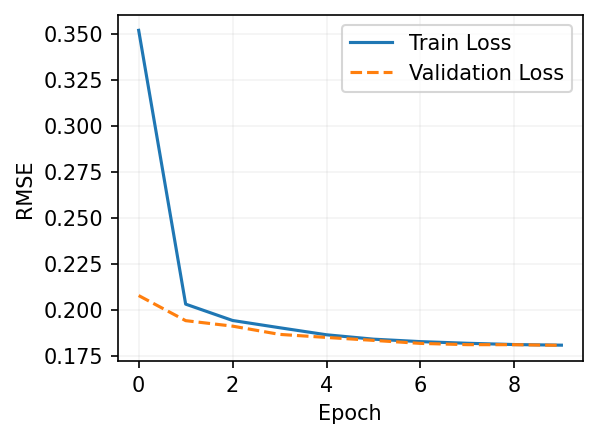

In [24]:
# Plot train / validation loss
plt.figure(figsize=(4,3), dpi=150)
plt.plot(np.sqrt(train_losses), label='Train Loss')
plt.plot(np.sqrt(val_losses), label='Validation Loss', ls='dashed')
plt.xlabel('Epoch')
plt.ylabel('RMSE')
# plt.ylim(0.09, 0.5)
plt.grid(alpha=0.15)
plt.legend()
plt.show()

## Run some diagnostics

**Purity / Completeness:**

* **wavelength-point level**: each wavelength point is treated as an independent classification:
  * TP: ground truth metal is present and the model predicts it
  * FP: no ground truth metal is present but the model predicts it
  * FN: ground truth metal is present but the model misses it
  * TN: neither ground truth nor prediction is present

    Point-level purity and completeness are therefore
     * purity       = TP / (TP + FP)
     * completeness = TP / (TP + FN)
       
* **spectrum level**: a spectrum is considered to contain a given metal species if at least one ground-truth wavelength point is labeled as active. A spectrum-level prediction is considered a valid detection when the predicted probability exceeds the given probability threshold (``prob_thresh``) and satisfies the minimum contiguous-point requirement (e.g. 3 contigious points = $\Delta \lambda = 0.6$ A). A predicted detection is a true positive only if it spatially overlaps at least one ground-truth metal point ($\Delta \lambda = 0.2$).

  
  * TP: metal is present and a predicted detection overlaps the GT
  * FN: metal is present but no predicted detection overlaps the GT
   * FP: a predicted detection exists but does not overlap the GT
   * TN: no metal is present and no detection is made

A prediction at the wrong wavelength in a spectrum that DOES contain a real absorber contributes to BOTH FP and FN: 
  * the true absorber was missed
  * AND the prediction was spurious.

Spectrum-level amplitude recovery is evaluated for true-positive detections. The predicted amplitude is summarized over the wavelength points belonging to the spatially matched detection and compared with the known injected amplitude.

In [25]:
def get_valid_pred_mask(
    prob_array: np.ndarray,
    p_thresh: float = 0.5,
    min_contiguous_points: int = 3,
) -> np.ndarray:
    """
    Identify valid predicted absorption regions in a 1D spectrum.

    The model produces a metal-detection probability at each wavelength
    point (0.2 A separation). This function first evaluates those 
    probabilities at a given threshold, ``p_thresh``. 

    A predicted region is considered valid if it contains at least
    ``min_contiguous_points`` consecutive wavelength points above the
    probability threshold. (e.g. 3 points = spanning 0.6 A in wavelength)

    This provides a simple spatial-consistency requirement for
    spectrum-level detections: a single high-probability point is not
    considered sufficient evidence for a detection when
    ``min_contiguous_points > 1``.

    Parameters
    ----------
    prob_array : np.ndarray
        One-dimensional array containing the predicted metal probability
        at each wavelength point in a single spectrum. Shape:

            (n_wavelength_points,)

        Values are expected to lie between 0 and 1.

    p_thresh : float, optional
        Minimum predicted probability required for a wavelength point to
        initially be considered positive.

        Default is 0.5.

    min_contiguous_points : int, optional
        Minimum number of consecutive above-threshold wavelength points
        required for a region to be considered a valid prediction.

        If set to 1, every point satisfying ``prob_array >= p_thresh``
        is retained.

        Default is 3, equivalent to Delta wavelength = 0.6 A 

    Returns
    -------
    np.ndarray
        Boolean array with the same shape as ``prob_array``.

        ``True`` identifies wavelength points belonging to an above-threshold
        contiguous region that satisfies the minimum length requirement.

    Notes
    -----
    This function operates only on the model prediction. It does not use
    ground-truth information.

    The function is intended primarily for defining spectrum-level
    detections. Point-level purity and completeness should generally be
    calculated directly from the probability threshold without applying
    this contiguous-region filter.
    """

    # --------------------------------------------------------------
    # Step 1: Apply threshold to the model probabilities
    # --------------------------------------------------------------
    # Each wavelength point is initially considered positive if its
    # predicted probability exceeds the requested detection threshold.
    binary_mask = prob_array >= p_thresh

    # No points exceed the threshold.
    if not np.any(binary_mask):
        return np.zeros_like(binary_mask, dtype=bool)

    # If only one point is required, no additional spatial filtering
    # is necessary.
    if min_contiguous_points <= 1:
        return binary_mask

    # --------------------------------------------------------------
    # Step 2: Identify contiguous above-threshold regions
    # --------------------------------------------------------------
    # Add False values at both ends so that regions touching the first
    # or last wavelength point are detected correctly.
    padded = np.concatenate(
        ([False], binary_mask, [False])
    )

    # Differences identify transitions:
    #
    #   False -> True : +1, start of a region
    #   True  -> False: -1, end of a region
    #
    changes = np.diff(
        padded.astype(np.int8)
    )

    starts = np.flatnonzero(changes == 1)
    ends = np.flatnonzero(changes == -1)

    # Length of each contiguous above-threshold region.
    lengths = ends - starts

    # Retain only regions satisfying the minimum length requirement.
    valid = lengths >= min_contiguous_points

    # --------------------------------------------------------------
    # Step 3: Construct the filtered prediction mask
    # --------------------------------------------------------------
    valid_mask = np.zeros_like(
        binary_mask,
        dtype=bool,
    )

    for start, end in zip(
        starts[valid],
        ends[valid],
    ):
        valid_mask[start:end] = True

    return valid_mask


def is_valid_spectrum_detection(
    prob_array: np.ndarray,
    p_thresh: float = 0.5,
    min_contiguous_points: int = 3,
) -> bool:
    """
    Determine whether a spectrum contains at least one valid predicted
    metal-detection region.

    This is a convenience wrapper around :func:`get_valid_pred_mask`.
    It applies the probability threshold and minimum contiguous-point
    requirement, then returns a single Boolean indicating whether any
    valid predicted region exists.

    Parameters
    ----------
    prob_array : np.ndarray
        One-dimensional predicted metal-probability array for one spectrum,
        with shape ``(n_wavelength_points,)``.

    p_thresh : float, optional
        Minimum predicted probability required for a wavelength point to
        be considered part of a candidate detection.

        Default is 0.5.

    min_contiguous_points : int, optional
        Minimum number of consecutive above-threshold wavelength points
        required for a valid detection.

        Default is 3.

    Returns
    -------
    bool
        ``True`` if at least one valid predicted region exists, otherwise
        ``False``.

    Notes
    -----
    This function does not use the ground-truth mask. It answers only:

        "Did the model produce a valid detection in this spectrum?"

    It therefore can be used on both mock spectra and real observational
    spectra.
    """

    valid_mask = get_valid_pred_mask(
        prob_array,
        p_thresh=p_thresh,
        min_contiguous_points=min_contiguous_points,
    )

    return np.any(valid_mask)


def get_threshold_detection_curve(
    prob_array: np.ndarray,
    gt_mask: np.ndarray,
    prob_sweep: np.ndarray,
    min_contiguous_points: int = 3,
):
    """
    Evaluate spectrum-level detection and spatial agreement over a range
    of probability thresholds.

    For each threshold in ``prob_sweep``, the model probabilities are
    converted into a valid predicted-region mask using
    :func:`get_valid_pred_mask`.

    Two separate quantities are returned:

    1. ``pred_exists``:
       Whether at least one valid predicted region exists in the spectrum.

    2. ``spatial_match``:
       Whether at least one valid predicted region overlaps at least one
       ground-truth metal wavelength point.

    These quantities are kept separate because a model can produce a
    prediction without correctly locating the ground-truth absorber.

    Parameters
    ----------
    prob_array : np.ndarray
        Predicted metal probabilities for one spectrum.

        Shape:
            ``(n_wavelength_points,)``

    gt_mask : np.ndarray
        Boolean ground-truth metal mask for the same spectrum and metal
        species.

        Shape:
            ``(n_wavelength_points,)``

        ``True`` indicates a wavelength point containing injected metal
        absorption.

    prob_sweep : np.ndarray
        One-dimensional array of probability thresholds to evaluate.

        For example::

            np.linspace(0.01, 0.99, 25)

    min_contiguous_points : int, optional
        Minimum number of consecutive above-threshold wavelength points
        required for a valid predicted region.

        Default is 3.

    Returns
    -------
    pred_exists : np.ndarray
        Boolean array with shape ``(len(prob_sweep),)``.

        ``pred_exists[i]`` is ``True`` when at least one valid predicted
        region exists at ``prob_sweep[i]``.

    spatial_match : np.ndarray
        Boolean array with shape ``(len(prob_sweep),)``.

        ``spatial_match[i]`` is ``True`` when at least one valid predicted
        region overlaps the ground-truth mask at ``prob_sweep[i]``.

    Notes
    -----
    This function requires ground-truth information because
    ``spatial_match`` is specifically a mock-data performance diagnostic.

    The resulting arrays are used to construct spectrum-level purity and
    completeness curves:

        TP = GT exists AND spatial_match
        FN = GT exists AND NOT spatial_match
        FP = prediction exists AND NOT spatial_match

    A prediction at the wrong location in a GT-positive spectrum therefore
    contributes to the false-positive count while the missed GT absorber
    contributes to the false-negative count.
    """

    pred_exists = np.zeros(
        len(prob_sweep),
        dtype=bool,
    )

    spatial_match = np.zeros(
        len(prob_sweep),
        dtype=bool,
    )

    for i, p_th in enumerate(prob_sweep):

        # Construct the valid predicted-region mask at this threshold.
        valid_mask = get_valid_pred_mask(
            prob_array,
            p_thresh=p_th,
            min_contiguous_points=min_contiguous_points,
        )

        # Did the model produce any valid detection?
        pred_exists[i] = np.any(valid_mask)

        # If so, does any predicted wavelength point overlap a
        # ground-truth metal wavelength point?
        if pred_exists[i]:
            spatial_match[i] = np.any(
                gt_mask & valid_mask
            )

    return pred_exists, spatial_match


def darken_color(
    color,
    factor: float = 0.65,
):
    """
    Darken a Matplotlib-compatible color by multiplying its RGB values.
    """

    if not 0.0 <= factor <= 1.0:
        raise ValueError(
            "factor must be between 0 and 1."
        )

    rgb = np.array(to_rgb(color))

    return tuple(rgb * factor)
    

In [26]:
def evaluate_unet_stats(
    model,
    val_loader,
    device,
    metal_names: list = None,
):
    """
    Evaluate basic detection-probability statistics for each metal species.

    For each metal species, a spectrum is considered to contain the metal if
    at least one wavelength point is labeled as active in the ground-truth
    mask. The model's spectrum-level detection statistic is the maximum
    predicted probability anywhere in that spectrum.

    Simple spectrum-level classification:

        max_probability >= threshold  -> metal predicted in spectrum
        max_probability < threshold   -> metal not predicted in spectrum

    From this classification, spectrum-level purity and completeness can be
    calculated in the usual binary-classification sense. 

    The function also reports the distribution of the true metal amplitudes
    and plots the distribution of maximum predicted probabilities for spectra
    containing each metal.

    Parameters
    ----------
    model : torch.nn.Module
        Trained U-Net model. The model must return classification logits and
        amplitude predictions when called as ``model(X)``.

    val_loader : torch.utils.data.DataLoader
        DataLoader containing the validation set. Each batch should contain
        ``(X, target_mask, target_amp)``.

    device : torch.device
        Device on which the model is evaluated.

    metal_names : list, optional
        Names of the metal species, in the same order as the species channels
        in the model output. If ``None``, species names are not available for
        labeling the diagnostics.

    Returns
    -------
    mean_gt_max_prob : list
        Mean maximum predicted probability for each metal among spectra that
        contain that metal according to the ground-truth mask.
    """

    model.eval()

    # ------------------------------------------------------------
    # Collect predictions and targets from the validation set.
    # ------------------------------------------------------------

    all_mask_true = []
    all_amp_true = []
    all_prob_pred = []
    all_amp_pred = []

    with torch.no_grad():
        for X_b, mask_b, amp_b in val_loader:

            X_b = X_b.to(device)

            logits_pred, amp_pred = model(X_b)
            probs_pred = torch.sigmoid(logits_pred)

            all_mask_true.append(mask_b.cpu().numpy())
            all_amp_true.append(amp_b.cpu().numpy())
            all_prob_pred.append(probs_pred.cpu().numpy())
            all_amp_pred.append(amp_pred.cpu().numpy())

    # Shapes:
    #
    #   mask_true : (N_spectra, N_species, N_wavelength_points)
    #   amp_true  : (N_spectra, N_species, N_wavelength_points)
    #   prob_pred : (N_spectra, N_species, N_wavelength_points)
    #   amp_pred  : (N_spectra, N_species, N_wavelength_points)

    mask_true = np.concatenate(all_mask_true, axis=0)

    amp_true = np.concatenate(all_amp_true, axis=0)
    amp_true = 10.0 ** amp_true

    prob_pred = np.concatenate(all_prob_pred, axis=0)
    amp_pred = np.concatenate(all_amp_pred, axis=0)

    # Number of spectra and metal species.
    n_spectra = mask_true.shape[0]
    n_species = mask_true.shape[1]
    n_wavelength_points = mask_true.shape[2]

    if metal_names is None:
        metal_names = [f"Species {i}" for i in range(n_species)]

    # ------------------------------------------------------------
    # Plot maximum predicted probability for each metal.
    # ------------------------------------------------------------

    fig, ax = plt.subplots(figsize=(8, 5))

    mean_gt_max_probs = []

    for m_idx, name in enumerate(metal_names):

        # A spectrum contains the metal if at least one wavelength point
        # is labeled as active in the ground-truth mask.
        gt_spec = np.any(
            mask_true[:, m_idx, :] > 0.5,
            axis=1,
        )

        # Boolean mask of GT-positive wavelength points. 
        active_points = mask_true[:, m_idx, :] > 0.5 
        
        # Number of GT-positive wavelength points in each spectrum. 
        gt_points_per_spectrum = active_points.sum(axis=1) 
        
        # Only consider spectra that actually contain the metal when 
        # calculating the number of positive points per spectrum. 
        gt_points_positive_spectra = gt_points_per_spectrum[gt_spec] 
        
        # Overall fraction of wavelength points that are GT-positive. 
        gt_point_fraction = active_points.mean()

        # -------------------------------------------------------- 
        # Point-level predicted probabilities. 
        # -------------------------------------------------------- 
        # Probability at every wavelength point for this metal.
        metal_prob = prob_pred[:, m_idx, :] 
        
        # Probabilities at GT-positive and GT-negative points. 
        gt_point_prob = metal_prob[active_points] 
        non_gt_point_prob = metal_prob[~active_points]

        # -------------------------------------------------------- 
        # Spectrum-level predicted probability. 
        # -------------------------------------------------------- 
        # Reduce the point-level probability prediction to one
        # spectrum-level detection statistic: the maximum probability. 
        max_prob = metal_prob.max(axis=1) 
        
        # Store the mean maximum probability for GT spectra. 
        mean_gt_max_probs.append( 
            max_prob[gt_spec].mean() 
            if np.any(gt_spec) 
            else np.nan 
        )        
        
        # --------------------------------------------------------
        # Basic probability statistics.
        # --------------------------------------------------------

        print(f"\n{name}")
        print("-" * len(name))

        print(f"GT spectra: {gt_spec.sum()} / {n_spectra}")

        print("\nGT-positive wavelength points:") 
        
        if np.any(gt_spec): 
            print(
                f" Mean points per GT spectrum: " 
                f"{gt_points_positive_spectra.mean():.2f}" 
            ) 
            print( 
                f" Median points per GT spectrum: " 
                f"{np.median(gt_points_positive_spectra):.2f}" 
            ) 
            print( 
                " 16/50/84% points per GT spectrum: " 
                f"{np.percentile(gt_points_positive_spectra, [16, 50, 84])}" 
            ) 
            print( f" Min / max points per GT spectrum: " 
                   f"{gt_points_positive_spectra.min()} / " f"{gt_points_positive_spectra.max()}" 
            ) 
            print( 
                f" Overall GT-positive point fraction: " 
                f"{gt_point_fraction:.6f} " 
                f"({100 * gt_point_fraction:.4f}%)" 
            )

        print("\nPredicted probability at wavelength points:") 
        
        if gt_point_prob.size > 0: 
            print(" GT-positive points:") 
            print( f" mean = {gt_point_prob.mean():.4f}" ) 
            print( f" median = {np.median(gt_point_prob):.4f}" ) 
            print( " 16/50/84% = " f"{np.percentile(gt_point_prob, [16, 50, 84])}" ) 
            
            if non_gt_point_prob.size > 0: 
                print(" GT-negative points:") 
                print( f" mean = {non_gt_point_prob.mean():.4f}" ) 
                print( f" median = {np.median(non_gt_point_prob):.4f}" ) 
                print( " 16/50/84% = " f"{np.percentile(non_gt_point_prob, [16, 50, 84])}" )


            
        if np.any(gt_spec):
            print(
                "Maximum predicted probability, GT spectra:"
            )
            print(
                f"  mean   = {max_prob[gt_spec].mean():.4f}"
            )
            print(
                f"  median = {np.median(max_prob[gt_spec]):.4f}"
            )
            print(
                "  16/50/84% = "
                f"{np.percentile(max_prob[gt_spec], [16, 50, 84])}"
            )

        if np.any(~gt_spec):
            print(
                "Maximum predicted probability, non-GT spectra:"
            )
            print(
                f"  mean   = {max_prob[~gt_spec].mean():.4f}"
            )
            print(
                f"  median = {np.median(max_prob[~gt_spec]):.4f}"
            )
            print(
                "  16/50/84% = "
                f"{np.percentile(max_prob[~gt_spec], [16, 50, 84])}"
            )

        # True amplitudes are stored as log10(A) in the dataset.
        # Here they have already been converted back to A.
        active_points = mask_true[:, m_idx, :] > 0.5

        if np.any(active_points):
            print(
                f"Mean true amplitude on GT points: "
                f"{amp_true[:, m_idx, :][active_points].mean():.4f}"
            )

        print(
            "Maximum predicted probability over all spectra "
            "(16/50/84%): "
            f"{np.percentile(max_prob, [16, 50, 84])}"
        )


        # # --------------------------------------------------------
        # # Spectrum-level purity and completeness using max P.
        # # --------------------------------------------------------

        # print("\nSpectrum-level detection:")
        
        # for threshold in [0.2, 0.4, 0.6, 0.8, 0.99]:

        #     # Predict that the metal is present somewhere in the spectrum
        #     # if its maximum predicted probability exceeds the threshold.
        #     pred_spec = max_prob >= threshold

        #     tp = np.sum(gt_spec & pred_spec)
        #     fp = np.sum(~gt_spec & pred_spec)
        #     fn = np.sum(gt_spec & ~pred_spec)
        #     tn = np.sum(~gt_spec & ~pred_spec)

        #     purity = (
        #         tp / (tp + fp)
        #         if (tp + fp) > 0
        #         else 0.0
        #     )

        #     completeness = (
        #         tp / (tp + fn)
        #         if (tp + fn) > 0
        #         else 0.0
        #     )

        #     print(
        #         f"  P >= {threshold:.2f}: "
        #         f"predicted={pred_spec.sum():4d}, "
        #         f"TP={tp:4d}, "
        #         f"FP={fp:4d}, "
        #         f"FN={fn:4d}, "
        #         f"TN={tn:4d}, "
        #         f"purity={purity:.3f}, "
        #         f"completeness={completeness:.3f}"
        #     )

        # --------------------------------------------------------
        # Spectrum-level purity and completeness using valid
        # contiguous predicted regions.
        # --------------------------------------------------------
        
        print("\nSpectrum-level detection:")
        print(
            "  Detection requires at least 3 contiguous wavelength "
            "points above the probability threshold."
        )
        
        for threshold in [0.2, 0.4, 0.6, 0.8, 0.99]:
        
            # Determine whether each spectrum contains at least one
            # valid predicted region.
            pred_spec = np.array([
                is_valid_spectrum_detection(
                    prob_pred[i, m_idx, :],
                    p_thresh=threshold,
                    min_contiguous_points=3,
                )
                for i in range(n_spectra)
            ])
        
            tp = np.sum(gt_spec & pred_spec)
            fp = np.sum(~gt_spec & pred_spec)
            fn = np.sum(gt_spec & ~pred_spec)
            tn = np.sum(~gt_spec & ~pred_spec)
        
            purity = (
                tp / (tp + fp)
                if (tp + fp) > 0
                else 0.0
            )
        
            completeness = (
                tp / (tp + fn)
                if (tp + fn) > 0
                else 0.0
            )
        
            print(
                f"  P >= {threshold:.2f}: "
                f"predicted={pred_spec.sum():4d}, "
                f"TP={tp:4d}, "
                f"FP={fp:4d}, "
                f"FN={fn:4d}, "
                f"TN={tn:4d}, "
                f"purity={purity:.3f}, "
                f"completeness={completeness:.3f}"
            )


        # --------------------------------------------------------
        # Probability histogram.
        # --------------------------------------------------------

        hist_color = CB_color_cycle[
            m_idx % len(CB_color_cycle)
        ]
        mean_color = darken_color(hist_color)

        if np.any(gt_spec):
            ax.hist(
                max_prob[gt_spec],
                bins=30,
                alpha=0.5,
                color=hist_color,
                label=f"{name} — GT",
            )

            ax.axvline(
                max_prob[gt_spec].mean(),
                linestyle="--",
                color=mean_color,
                linewidth=2,
                label=f"{name} mean",
            )


    ax.set_xlabel(
        "Maximum predicted probability per spectrum"
    )
    ax.set_ylabel("Number of spectra")
    ax.legend()

    plt.show()

    return mean_gt_max_probs

In [27]:
# def longest_contiguous_run(mask):
#     if not np.any(mask):
#         return 0

#     padded = np.concatenate(([False], mask, [False]))
#     changes = np.diff(padded.astype(np.int8))
#     starts = np.flatnonzero(changes == 1)
#     ends = np.flatnonzero(changes == -1)

#     return np.max(ends - starts)
    

# def temp_diagnostic(
#     model,
#     val_loader,
#     device,
#     metal_names: list = None,
#     ):
    
#     model.eval()

#     # ------------------------------------------------------------
#     # Collect predictions and targets from the validation set.
#     # ------------------------------------------------------------

#     all_mask_true = []
#     all_amp_true = []
#     all_prob_pred = []
#     all_amp_pred = []

#     with torch.no_grad():
#         for X_b, mask_b, amp_b in val_loader:

#             X_b = X_b.to(device)

#             logits_pred, amp_pred = model(X_b)
#             probs_pred = torch.sigmoid(logits_pred)

#             all_mask_true.append(mask_b.cpu().numpy())
#             all_amp_true.append(amp_b.cpu().numpy())
#             all_prob_pred.append(probs_pred.cpu().numpy())
#             all_amp_pred.append(amp_pred.cpu().numpy())

#     # Shapes:
#     #
#     #   mask_true : (N_spectra, N_species, N_wavelength_points)
#     #   amp_true  : (N_spectra, N_species, N_wavelength_points)
#     #   prob_pred : (N_spectra, N_species, N_wavelength_points)
#     #   amp_pred  : (N_spectra, N_species, N_wavelength_points)

#     mask_true = np.concatenate(all_mask_true, axis=0)

#     amp_true = np.concatenate(all_amp_true, axis=0)
#     amp_true = 10.0 ** amp_true

#     prob_pred = np.concatenate(all_prob_pred, axis=0)
#     amp_pred = np.concatenate(all_amp_pred, axis=0)

#     # Number of spectra and metal species.
#     n_spectra = mask_true.shape[0]
#     n_species = mask_true.shape[1]
#     n_wavelength_points = mask_true.shape[2]

#     if metal_names is None:
#         metal_names = [f"Species {i}" for i in range(n_species)]

#     i = 0
#     m_idx = metal_names.index("SiII_1190")
    
#     print("X shape:", X_b.shape)
    
#     # assuming channel 0 is Lyα and channel m_idx + 1 is the
#     # corresponding metal-specific input channel
#     metal_channel = X_b[i, m_idx + 1, :]
    
#     pred_prob = prob_pred[i, m_idx, :]
    
#     print("Metal-channel range:")
#     print(np.min(metal_channel), np.max(metal_channel))
    
#     print("Predicted probability range:")
#     print(np.min(pred_prob), np.max(pred_prob))

#     fig, ax = plt.subplots(figsize=(12, 4))

#     ax.plot(metal_channel, label="metal input channel")
#     ax.plot(pred_prob, label="predicted probability")
    
#     ax.set_xlabel("Wavelength point")
#     ax.set_ylabel("Value")
#     ax.legend()
#     plt.show()

            
# temp_diagnostic(
#     model=model,
#     val_loader=val_loader,
#     device=device,
#     metal_names=species_names,
# )

In [28]:
def evaluate_unet_mock_performance(
    model,
    val_loader,
    device,
    metal_names: list = None,
    prob_thresh: Union[float, Dict[str, float], List[float]] = 0.5,
    min_contiguous_points: Union[int, Dict[str, int], List[int]] = 3,
    inputs_in_log_space: bool = True,
    plot: bool = True,
    print_stats: bool = True,
):
    """
    Evaluate a trained U-Net on mock spectra with known ground-truth metal
    absorption.

    This function evaluates both wavelength-point-level and spectrum-level
    detection performance. Because the validation data are synthetic mocks,
    the true locations and amplitudes of injected metal absorption are known.

    At the wavelength-point level, each wavelength point is treated as an
    independent classification:

        TP: ground truth metal is present and the model predicts it
        FP: no ground truth metal is present but the model predicts it
        FN: ground truth metal is present but the model misses it
        TN: neither ground truth nor prediction is present

    Point-level purity and completeness are therefore

        purity       = TP / (TP + FP)
        completeness = TP / (TP + FN)

    At the spectrum level, a spectrum is considered to contain a given metal
    if at least one ground-truth wavelength point is labeled as active.

    A spectrum-level prediction is considered a valid detection when the
    predicted probability exceeds ``prob_thresh`` and satisfies the minimum
    contiguous-point requirement. A predicted detection is a true positive
    only if it spatially overlaps at least one ground-truth metal point.

        TP: metal is present and a predicted detection overlaps the GT
        FN: metal is present but no predicted detection overlaps the GT
        FP: a predicted detection exists but does not overlap the GT
        TN: no metal is present and no detection is made

    Consequently, a prediction at the wrong wavelength in a spectrum that
    contains a real absorber contributes to both FP and FN: the true absorber
    was missed, and the prediction was spurious.

    Spectrum-level amplitude recovery is evaluated for true-positive
    detections. The predicted amplitude is summarized over the wavelength
    points belonging to the spatially matched detection and compared with the
    known injected amplitude.

    Parameters
    ----------
    model : torch.nn.Module
        Trained U-Net model. The model must return two tensors:

            mask_logits : [B, num_species, N_wavelength_points]
            amp_pred    : [B, num_species, N_wavelength_points]

        where ``mask_logits`` are classification logits and ``amp_pred`` is
        the predicted log10 metal amplitude.

    val_loader : torch.utils.data.DataLoader
        Validation DataLoader containing mock spectra and their ground-truth
        labels. Each batch must contain:

            X_b    : model input spectra
            mask_b : binary ground-truth metal masks
            amp_b  : ground-truth log10 metal amplitudes

    device : torch.device
        Device on which the model is evaluated, e.g. ``cuda`` or ``cpu``.

    metal_names : list of str, optional
        Names of the metal species, in the same order as the species dimension
        of the model outputs. If None, generic names are generated.

    prob_thresh : float, list, tuple, or dict, optional
        Detection-probability threshold used for the reported metrics.

        - scalar: same threshold for every species
        - list/tuple: one threshold per species
        - dict: threshold keyed by species name

        Default is 0.5.

    min_contiguous_points : int, list, tuple, or dict, optional
        Minimum number of contiguous wavelength points required for a predicted
        region to count as a spectrum-level detection.

        - scalar: same requirement for every species
        - list/tuple: one requirement per species
        - dict: requirement keyed by species name

        This criterion is applied only to spectrum-level detection. Point-level
        metrics use the probability threshold directly.

        Default is 3.

    inputs_in_log_space : bool, optional
        Whether the amplitude targets and predictions are stored in log10(A).
        If True, they are converted to linear amplitude A before calculating
        amplitude-recovery statistics.

        Default is True.

    plot : bool, optional
        If True, generate diagnostic plots. Plotting can be relatively
        expensive for large validation sets.

        Default is True.

    print_stats : bool, optional
        If True, print numerical evaluation statistics.

        Default is True.

    Returns
    -------
    None
        The function prints and optionally plots evaluation diagnostics. It
        does not currently return the calculated metrics.

    Notes
    -----
    These metrics are appropriate for mock data because the ground-truth
    metal absorption is known. They cannot be directly calculated on
    unlabeled observational spectra, where the true absorber locations and
    amplitudes are unknown.

    The probability-threshold curves show how purity and completeness change
    as the detection threshold is varied from 0.01 to 0.99.
    """

    model.eval()

    # ------------------------------------------------------------------
    # Collect model predictions and ground-truth labels
    # ------------------------------------------------------------------
    all_mask_true = []
    all_amp_true = []
    all_prob_pred = []
    all_amp_pred = []

    with torch.no_grad():
        for X_b, mask_b, amp_b in val_loader:

            X_b = X_b.to(device)

            # Model outputs:
            #   logits_pred -> classification logits
            #   amp_pred    -> predicted log10 amplitude
            logits_pred, amp_pred = model(X_b)

            # Convert classification logits to probabilities.
            probs_pred = torch.sigmoid(logits_pred)

            all_mask_true.append(mask_b.cpu().numpy())
            all_amp_true.append(amp_b.cpu().numpy())
            all_prob_pred.append(probs_pred.cpu().numpy())
            all_amp_pred.append(amp_pred.cpu().numpy())

    # Shape:
    #   (N_spectra, N_species, N_wavelength_points)
    mask_true = np.concatenate(all_mask_true, axis=0)
    amp_true = np.concatenate(all_amp_true, axis=0)
    prob_pred = np.concatenate(all_prob_pred, axis=0)
    amp_pred = np.concatenate(all_amp_pred, axis=0)

    # Convert amplitudes from log10(A) to linear A for reporting.
    if inputs_in_log_space:
        amp_true = 10.0 ** amp_true
        amp_pred = 10.0 ** amp_pred

    num_spectra, num_species, num_wavelength_points = mask_true.shape

    if metal_names is None:
        metal_names = [
            f"Species_{i+1}"
            for i in range(num_species)
        ]

    # Probability thresholds used to construct purity/completeness curves.
    prob_sweep = np.linspace(0.01, 0.99, 25)

    # ------------------------------------------------------------------
    # Evaluate each metal species independently
    # ------------------------------------------------------------------
    for m_idx, species_name in enumerate(metal_names):

        # ==============================================================
        # Resolve species-specific detection parameters
        # ==============================================================

        if isinstance(prob_thresh, dict):
            current_p_thresh = prob_thresh.get(species_name, 0.5)
        elif isinstance(prob_thresh, (list, tuple)):
            current_p_thresh = prob_thresh[m_idx]
        else:
            current_p_thresh = float(prob_thresh)

        if isinstance(min_contiguous_points, dict):
            current_min_contig = min_contiguous_points.get(
                species_name,
                3,
            )
        elif isinstance(min_contiguous_points, (list, tuple)):
            current_min_contig = min_contiguous_points[m_idx]
        else:
            current_min_contig = int(min_contiguous_points)

        # ==============================================================
        # Extract this species
        # ==============================================================

        # Flatten spectra and wavelength points together for point-level
        # classification statistics.
        m_mask_true = mask_true[:, m_idx, :].ravel()
        m_amp_true = amp_true[:, m_idx, :].ravel()
        m_prob_pred = prob_pred[:, m_idx, :].ravel()
        m_amp_pred = amp_pred[:, m_idx, :].ravel()

        # Ground-truth metal presence at each wavelength point.
        is_true = m_mask_true > 0.5

        # Point-level prediction using only the probability threshold.
        is_pred = m_prob_pred >= current_p_thresh

        # Point-level confusion matrix.
        is_tp = is_true & is_pred
        is_fp = ~is_true & is_pred
        is_fn = is_true & ~is_pred
        is_tn = ~is_true & ~is_pred

        tp_point = np.sum(is_tp)
        fp_point = np.sum(is_fp)
        fn_point = np.sum(is_fn)
        tn_point = np.sum(is_tn)

        # Point-level purity = fraction of predicted positive points
        # that correspond to ground-truth metal absorption.
        point_purity = (
            tp_point / (tp_point + fp_point)
            if (tp_point + fp_point) > 0
            else 0.0
        )

        # Point-level completeness = fraction of ground-truth metal
        # points that are successfully recovered.
        point_completeness = (
            tp_point / (tp_point + fn_point)
            if (tp_point + fn_point) > 0
            else 0.0
        )

        # ==============================================================
        # Point-level purity/completeness as a function of threshold
        # ==============================================================

        purities_point = []
        completenesses_point = []

        for p_th in prob_sweep:

            predicted_points = m_prob_pred >= p_th

            tp_i = np.sum(is_true & predicted_points)
            fp_i = np.sum(~is_true & predicted_points)
            fn_i = np.sum(is_true & ~predicted_points)

            purity_i = (
                tp_i / (tp_i + fp_i)
                if (tp_i + fp_i) > 0
                else 1.0
            )

            completeness_i = (
                tp_i / (tp_i + fn_i)
                if (tp_i + fn_i) > 0
                else 1.0
            )

            purities_point.append(purity_i)
            completenesses_point.append(completeness_i)

        # ==============================================================
        # Ground-truth spectrum-level information
        # ==============================================================

        # A spectrum contains this metal if at least one wavelength point
        # is labeled as ground-truth metal absorption.
        gt_points_all = mask_true[:, m_idx, :] > 0.5
        gt_exists_all = np.any(gt_points_all, axis=1)

        num_gt_spectra = np.sum(gt_exists_all)
        num_non_gt_spectra = np.sum(~gt_exists_all)

        # ==============================================================
        # Spectrum-level evaluation at requested threshold
        # ==============================================================

        tp_spec = 0
        fp_spec = 0
        fn_spec = 0
        tn_spec = 0

        # Store amplitude/probability information for true-positive
        # spectrum-level detections.
        spec_true_amplitudes = []
        spec_pred_amplitudes = []
        spec_pred_probabilities = []

        # ==============================================================
        # Threshold-independent arrays for the threshold sweep
        # ==============================================================

        all_pred_exists = np.zeros(
            (num_spectra, len(prob_sweep)),
            dtype=bool,
        )

        all_spatial_match = np.zeros(
            (num_spectra, len(prob_sweep)),
            dtype=bool,
        )

        # ==============================================================
        # Evaluate each spectrum
        # ==============================================================

        for s_idx in range(num_spectra):

            gt_points = gt_points_all[s_idx]
            gt_exists = gt_exists_all[s_idx]
            prob_array = prob_pred[s_idx, m_idx, :]

            # ----------------------------------------------------------
            # Detection at the requested threshold
            # ----------------------------------------------------------

            predicted_mask = get_valid_pred_mask(
                prob_array,
                p_thresh=current_p_thresh,
                min_contiguous_points=current_min_contig,
            )

            pred_exists = np.any(predicted_mask)

            # A detection is spatially matched if at least one predicted
            # wavelength point overlaps a ground-truth metal point.
            spatial_match = np.any(
                gt_points & predicted_mask
            )

            # ----------------------------------------------------------
            # Spectrum-level confusion matrix
            # ----------------------------------------------------------

            if gt_exists:

                # The true injected absorber exists in this spectrum.
                #
                # True positive requires both:
                #   1. a predicted detection, and
                #   2. spatial overlap with the GT absorber.
                if spatial_match:

                    tp_spec += 1

                    # Points belonging to the spatially matched detection.
                    matched_points = gt_points & predicted_mask

                    # The mock has a single injected amplitude for this
                    # species, so use the median / mean predicted amplitude over
                    # the matched region.
                    spec_true_amplitudes.append(
                        # np.median(
                        np.mean(
                            amp_true[
                                s_idx,
                                m_idx,
                                gt_points,
                            ]
                        )
                    )

                    spec_pred_amplitudes.append(
                        # np.median(
                        np.mean(
                            amp_pred[
                                s_idx,
                                m_idx,
                                matched_points,
                            ]
                        )
                    )

                    # Record the maximum probability assigned anywhere
                    # in the spectrum.
                    spec_pred_probabilities.append(
                        np.max(prob_array)
                    )

                else:

                    # The spectrum contains a real absorber, but it was not
                    # successfully localized by the model.
                    fn_spec += 1

                    # If the model nevertheless produced a detection at the
                    # wrong location, that detection is also a false
                    # positive.
                    if pred_exists:
                        fp_spec += 1

            else:

                # No ground-truth absorber exists in this spectrum.
                if pred_exists:
                    fp_spec += 1
                else:
                    tn_spec += 1

            # ----------------------------------------------------------
            # Evaluate this spectrum for every probability threshold
            # ----------------------------------------------------------

            pred_exists_curve, spatial_match_curve = (
                get_threshold_detection_curve(
                    prob_array=prob_array,
                    gt_mask=gt_points,
                    prob_sweep=prob_sweep,
                    min_contiguous_points=current_min_contig,
                )
            )

            all_pred_exists[s_idx, :] = pred_exists_curve
            all_spatial_match[s_idx, :] = spatial_match_curve

        # ==============================================================
        # Spectrum-level purity and completeness
        # ==============================================================

        spectrum_purity = (
            tp_spec / (tp_spec + fp_spec)
            if (tp_spec + fp_spec) > 0
            else 0.0
        )

        spectrum_completeness = (
            tp_spec / (tp_spec + fn_spec)
            if (tp_spec + fn_spec) > 0
            else 0.0
        )

        # ==============================================================
        # Spectrum-level amplitude recovery
        # ==============================================================

        spec_true_amplitudes = np.asarray(spec_true_amplitudes)
        spec_pred_amplitudes = np.asarray(spec_pred_amplitudes)
        spec_pred_probabilities = np.asarray(
            spec_pred_probabilities
        )

        if len(spec_true_amplitudes) > 0:

            # True amplitudes should be identical for the fixed-amplitude
            # mock setup, but take the median / mean for robustness.
            # true_a0 = np.median(
            true_a0 = np.mean(
                spec_true_amplitudes)

            # predicted_median = np.median(
            predicted_mean = np.mean(
                spec_pred_amplitudes
            )

            p16, p84 = np.percentile(
                spec_pred_amplitudes,
                [16, 84],
            )

            sigma_68 = (p84 - p16) / 2.0

            amplitude_bias = (
                # predicted_median - true_a0
                predicted_mean - true_a0
            )

            amplitude_mae = np.mean(
                np.abs(
                    spec_pred_amplitudes - spec_true_amplitudes
                )
            )

        else:

            true_a0 = 0.0
            # predicted_median = 0.0
            predicted_mean = 0.0
            p16 = 0.0
            p84 = 0.0
            sigma_68 = 0.0
            amplitude_bias = 0.0
            amplitude_mae = 0.0

        # ==============================================================
        # Spectrum-level purity/completeness threshold curve
        # ==============================================================

        purities_spectrum = []
        completenesses_spectrum = []

        for i, p_th in enumerate(prob_sweep):

            pred_exists = all_pred_exists[:, i]
            spatial_match = all_spatial_match[:, i]

            # True positive:
            #   GT absorber exists AND predicted detection overlaps it.
            tp_i = np.sum(
                gt_exists_all & spatial_match
            )

            # False negative:
            #   GT absorber exists BUT no overlapping prediction.
            fn_i = np.sum(
                gt_exists_all & ~spatial_match
            )

            # False positive:
            #   prediction exists BUT does not overlap a GT absorber.
            #
            # In a GT-positive spectrum, a wrong-location detection
            # therefore contributes to FP while the missed GT contributes
            # to FN.
            fp_i = np.sum(
                pred_exists & ~spatial_match
            )

            purity_i = (
                tp_i / (tp_i + fp_i)
                if (tp_i + fp_i) > 0
                else 1.0
            )

            completeness_i = (
                tp_i / (tp_i + fn_i)
                if (tp_i + fn_i) > 0
                else 1.0
            )

            purities_spectrum.append(purity_i)
            completenesses_spectrum.append(completeness_i)

        # ==============================================================
        # Print summary statistics
        # ==============================================================

        if print_stats:

            print("\n" + "=" * 65)
            print(
                f" MOCK EVALUATION: {species_name}"
            )
            print("=" * 65)

            print(
                f"Total spectra:        {num_spectra}"
            )
            print(
                f"GT-positive spectra:  {num_gt_spectra}"
            )
            print(
                f"GT-negative spectra:  {num_non_gt_spectra}"
            )

            # ----------------------------------------------------------
            # Point-level metrics
            # ----------------------------------------------------------

            print("\n" + "-" * 65)
            print(
                f"POINT-LEVEL CLASSIFICATION "
                f"(p >= {current_p_thresh:.2f})"
            )
            print("-" * 65)

            print(
                f"True Positives:       {tp_point:8d}"
            )
            print(
                f"False Positives:      {fp_point:8d}"
            )
            print(
                f"False Negatives:      {fn_point:8d}"
            )
            print(
                f"True Negatives:       {tn_point:8d}"
            )

            print(
                f"Purity:               {point_purity:.4f}"
            )
            print(
                f"Completeness:         {point_completeness:.4f}"
            )

            # ----------------------------------------------------------
            # Spectrum-level metrics
            # ----------------------------------------------------------

            print("\n" + "-" * 65)
            print(
                f"SPECTRUM-LEVEL CLASSIFICATION "
                f"(p >= {current_p_thresh:.2f})"
            )
            print(
                f"Minimum contiguous points: "
                f"{current_min_contig}"
            )
            print("-" * 65)

            print(
                f"True Positives:       {tp_spec:8d}"
            )
            print(
                f"False Positives:      {fp_spec:8d}"
            )
            print(
                f"False Negatives:      {fn_spec:8d}"
            )
            print(
                f"True Negatives:       {tn_spec:8d}"
            )

            print(
                f"Purity:               {spectrum_purity:.4f}"
            )
            print(
                f"Completeness:         {spectrum_completeness:.4f}"
            )

            # ----------------------------------------------------------
            # Amplitude recovery
            # ----------------------------------------------------------

            print("\n" + "-" * 65)
            print(
                "SPECTRUM-LEVEL AMPLITUDE RECOVERY"
            )
            print("-" * 65)

            print(
                f"GT amplitude:         {true_a0:.5f}"
            )
            print(
                f"Detected GT spectra:  "
                f"{len(spec_pred_amplitudes):4d} / "
                f"{num_gt_spectra}"
            )
            print(
                # f"Predicted median:     "
                # f"{predicted_median:.4f}"
                f"Predicted mean:     "
                f"{predicted_mean:.5f}"
            )
            print(
                f"Bias (pred - true):   "
                f"{amplitude_bias:+.5f}"
            )
            print(
                f"68% spread:           "
                f"{sigma_68:.5f}"
            )
            print(
                f"Amplitude MAE:        "
                f"{amplitude_mae:.5f}"
            )

            print("=" * 65)

        # ==============================================================
        # Diagnostic plots
        # ==============================================================

        if plot:

            fig, axes = plt.subplots(
                1,
                3,
                figsize=(19, 5),
            )

            base_color = CB_color_cycle[
                m_idx % len(CB_color_cycle)
            ]

            # median_color = darken_color(
            mean_color = darken_color(
                base_color,
                factor=0.65,
            )

            # ----------------------------------------------------------
            # 1. Amplitude recovery
            # ----------------------------------------------------------

            if len(spec_pred_amplitudes) > 0:

                axes[0].hist(
                    spec_pred_amplitudes,
                    bins=30,
                    density=True,
                    color=base_color,
                    alpha=0.7,
                    edgecolor="black",
                )

                axes[0].axvline(
                    true_a0,
                    color="black",
                    linestyle="--",
                    lw=2,
                    label=f"True $A_0$ ({true_a0:.4f})",
                )

                axes[0].axvline(
                    # predicted_median,
                    # color=median_color,
                    predicted_mean,
                    color=mean_color,
                    linestyle="-",
                    lw=2,
                    label=(
                        # f"Pred. median "
                        # f"({predicted_median:.4f})"
                        f"Pred. mean "
                        f"({predicted_mean:.4f})"
                    ),
                )

                axes[0].axvspan(
                    p16,
                    p84,
                    color=base_color,
                    alpha=0.25,
                    label=(
                        f"68% interval "
                        f"[{p16:.3f}, {p84:.3f}]"
                    ),
                )

                axes[0].set_xlabel(
                    "Predicted Metal Amplitude, $A$"
                )

                axes[0].set_ylabel(
                    "Probability Density"
                )

                axes[0].set_title(
                    "Spectrum-Level Amplitude Recovery\n"
                    f"Bias: {amplitude_bias:+.4f} | "
                    f"$\\sigma_{{68}}$: {sigma_68:.4f}"
                )

                axes[0].grid(
                    True,
                    alpha=0.3,
                )

                axes[0].legend(
                    loc="upper right"
                )

            else:

                axes[0].text(
                    0.5,
                    0.5,
                    "No Detected Spectra",
                    ha="center",
                    va="center",
                )

            # ----------------------------------------------------------
            # 2. Spectrum-level purity/completeness
            # ----------------------------------------------------------

            axes[1].plot(
                prob_sweep,
                purities_spectrum,
                label="Spectrum Purity",
                color="teal",
                lw=2,
            )

            axes[1].plot(
                prob_sweep,
                completenesses_spectrum,
                label="Spectrum Completeness",
                color="darkorange",
                lw=2,
            )

            axes[1].axvline(
                current_p_thresh,
                color="gray",
                linestyle=":",
                label=(
                    f"Current Threshold "
                    f"({current_p_thresh:.2f})"
                ),
            )

            axes[1].set_xlabel(
                "Detection Probability Threshold"
            )

            axes[1].set_ylabel(
                "Fraction"
            )

            axes[1].set_title(
                "Spectrum-Level Purity & Completeness\n"
                f"Minimum contiguous points = "
                f"{current_min_contig}"
            )

            axes[1].set_xlim(
                prob_sweep.min(),
                prob_sweep.max(),
            )

            axes[1].set_ylim(
                0,
                1.05,
            )

            axes[1].grid(
                True,
                alpha=0.3,
            )

            axes[1].legend(
                loc="best"
            )

            # ----------------------------------------------------------
            # 3. Point-level purity/completeness
            # ----------------------------------------------------------

            axes[2].plot(
                prob_sweep,
                purities_point,
                label="Point Purity",
                color="teal",
                lw=2,
            )

            axes[2].plot(
                prob_sweep,
                completenesses_point,
                label="Point Completeness",
                color="darkorange",
                lw=2,
            )

            axes[2].axvline(
                current_p_thresh,
                color="gray",
                linestyle=":",
                label=(
                    f"Current Threshold "
                    f"({current_p_thresh:.2f})"
                ),
            )

            axes[2].set_xlabel(
                "Detection Probability Threshold"
            )

            axes[2].set_ylabel(
                "Fraction"
            )

            axes[2].set_title(
                "Point-Level Purity & Completeness"
            )

            axes[2].set_xlim(
                prob_sweep.min(),
                prob_sweep.max(),
            )

            axes[2].set_ylim(
                0,
                1.05,
            )

            axes[2].grid(
                True,
                alpha=0.3,
            )

            axes[2].legend(
                loc="best"
            )

            # ----------------------------------------------------------
            # Figure formatting
            # ----------------------------------------------------------

            plt.suptitle(
                f"Mock Evaluation Summary: {species_name}",
                fontsize=14,
                y=0.99,
            )

            plt.tight_layout()
            plt.show()
            

In [29]:
def evaluate_unet_predictions(
    model,
    data_loader,
    device,
    metal_names: list = None,
    log_wave_grid: np.ndarray = None,
    prob_thresh: Union[float, Dict[str, float], List[float]] = 0.5,
    min_contiguous_points: Union[int, Dict[str, int], List[int]] = 3,
    inputs_in_log_space: bool = True,
    plot: bool = True,
    print_stats: bool = True,
    a_true: list = None,
):
    """
    Evaluate and summarize U-Net predictions for spectra without
    requiring ground-truth metal labels.

    This function is intended for application to real or otherwise
    unlabeled spectra. It characterizes the metal absorption regions
    predicted by the model, but does not calculate purity,
    completeness, true positives, false positives, or amplitude
    recovery bias, since these quantities require ground-truth labels.

    A valid detection is defined as a contiguous region containing at
    least ``min_contiguous_points`` wavelength points for which the
    predicted metal probability exceeds ``prob_thresh``.

    Each valid predicted region is treated as an individual detection.
    The function records the location, size, probability, and predicted
    amplitude of each detection rather than averaging the model output
    over the entire spectrum.

    Parameters
    ----------
    model : torch.nn.Module
        Trained U-Net model. The model must return two tensors:

        ``mask_logits``
            Classification logits with shape
            ``(batch, num_species, num_points)``.

        ``amp_pred``
            Predicted log10 metal amplitudes with the same shape.

    data_loader : torch.utils.data.DataLoader
        DataLoader containing the spectra to evaluate.

        The function only uses the input spectra ``X_b`` from each
        batch. Ground-truth masks and amplitudes, if present in the
        dataset, are ignored.

    device : torch.device
        Device on which the model is evaluated.

    metal_names : list, optional
        Names of the metal species corresponding to the model output
        channels. The ordering must match the ordering used when the
        model was constructed.

        If None, generic names ``Species_1``, ``Species_2``, etc. are
        used.

    log_wave_grid : np.ndarray, optional
        One-dimensional uniformly spaced logarithmic wavelength grid
        corresponding to the spectral points.

        If provided, the logarithmic grid is converted to wavelength
        using ``exp(log_wave_grid)`` and the detection catalog includes
        the physical wavelength range of each predicted region.

        If None, detection locations are reported only in terms of
        point indices.

    prob_thresh : float, list, or dict, optional
        Minimum predicted probability required for a wavelength point
        to be considered part of a detection.

        Can be specified as:

        * a single scalar applied to all species,
        * a list/tuple containing one threshold per species, or
        * a dictionary keyed by species name.

        Default is 0.5.

    min_contiguous_points : int, list, or dict, optional
        Minimum number of consecutive wavelength points above the
        probability threshold required for a valid detection.

        Can be specified as:

        * a single integer applied to all species,
        * a list/tuple containing one value per species, or
        * a dictionary keyed by species name.

        Default is 3.

    inputs_in_log_space : bool, optional
        If True, the model amplitude output is interpreted as
        ``log10(A)`` and converted to linear amplitude before being
        reported.

        Default is True.

    plot : bool, optional
        If True, produce diagnostic plots summarizing the predicted
        detections.

    print_stats : bool, optional
        If True, print summary statistics for each metal species.

    a_true : list, optional 
    True metal amplitudes corresponding to ``metal_names``. 
    
    For example:: a_true = [0.002, 0.005, 0.001] 
    
    If provided, the function compares each true amplitude 
    with the mean predicted amplitude across all detected 
    regions for that species and reports the RMSE. 
    The length must match the number of species. 
    Default is None.

    Returns
    -------
    detection_catalog : list of dict
        List containing one dictionary for each predicted detection.

        Each dictionary contains:

        ``spectrum_index``
            Index of the spectrum in the input DataLoader.

        ``species``
            Name of the predicted metal species.

        ``start_point``
            Index of the first wavelength point in the detected region.

        ``end_point``
            Index of the last wavelength point in the detected region.

        ``n_points``
            Number of wavelength points in the detected region.

        ``start_wavelength``
            Physical wavelength of the first point, if
            ``log_wave_grid`` is provided.

        ``end_wavelength``
            Physical wavelength of the last point, if
            ``log_wave_grid`` is provided.

        ``max_probability``
            Maximum predicted metal probability within the region.

        ``mean_probability``
            Mean predicted probability within the region.

        ``median_probability``
            Median predicted probability within the region.

        ``median_amplitude``
            Median predicted metal amplitude within the region.

        ``mean_amplitude``
            Mean predicted metal amplitude within the region.

        ``max_amplitude``
            Maximum predicted metal amplitude within the region.

    Notes
    -----
    The returned amplitudes describe the model's prediction for each
    detected region. They should not be interpreted as measurements of
    the true metal absorption strength without an independent
    validation/calibration procedure.

    The ``min_contiguous_points`` criterion is applied to the
    probability prediction only. It is intended to suppress isolated
    high-probability points that are unlikely to represent a coherent
    absorption feature.

    Because the model predicts each metal species independently, a
    spectrum may contain zero, one, or multiple predicted regions for
    a given species.
    """

    model.eval()

    # --------------------------------------------------------------
    # Collect model predictions
    # --------------------------------------------------------------
    all_prob_pred = []
    all_amp_pred = []

    with torch.no_grad():

        for batch in data_loader:

            # The dataset may contain (X, mask, amp), but only X is
            # required when evaluating unlabeled / real data.
            X_b = batch[0].to(device)

            logits_pred, amp_pred = model(X_b)

            probs_pred = torch.sigmoid(logits_pred)

            all_prob_pred.append(
                probs_pred.cpu().numpy()
            )

            all_amp_pred.append(
                amp_pred.cpu().numpy()
            )

    prob_pred = np.concatenate(
        all_prob_pred,
        axis=0,
    )

    amp_pred = np.concatenate(
        all_amp_pred,
        axis=0,
    )

    # Convert predicted log10(A) to linear amplitude.
    if inputs_in_log_space:
        amp_pred = 10.0 ** amp_pred

    num_spectra, num_species, num_points = prob_pred.shape

    # --------------------------------------------------------------
    # Species names
    # --------------------------------------------------------------
    if metal_names is None:
        metal_names = [
            f"Species_{i+1}"
            for i in range(num_species)
        ]

    # -------------------------------------------------------------- 
    # True amplitudes 
    # -------------------------------------------------------------- 
    if a_true is not None: 
        a_true = np.asarray(a_true, dtype=float) 
        
        if len(a_true) != num_species: 
            raise ValueError( "a_true must contain one amplitude for each species. " 
                              f"Expected {num_species}, got {len(a_true)}." )

    # --------------------------------------------------------------
    # Wavelength grid
    # --------------------------------------------------------------
    if log_wave_grid is not None:

        log_wave_grid = np.asarray(log_wave_grid)

        if len(log_wave_grid) != num_points:
            raise ValueError(
                "log_wave_grid must have the same number of points "
                "as the model output."
            )

        wave_grid = np.exp(log_wave_grid)

    else:
        wave_grid = None

    # --------------------------------------------------------------
    # Detection catalog
    # --------------------------------------------------------------
    detection_catalog = []

    # Also keep summary information by species.
    species_stats = {}

    for m_idx, species_name in enumerate(metal_names):

        # ----------------------------------------------------------
        # Resolve species-specific probability threshold
        # ----------------------------------------------------------
        if isinstance(prob_thresh, dict):

            current_p_thresh = prob_thresh.get(
                species_name,
                0.5,
            )

        elif isinstance(prob_thresh, (list, tuple)):

            current_p_thresh = prob_thresh[m_idx]

        else:

            current_p_thresh = float(prob_thresh)

        # ----------------------------------------------------------
        # Resolve species-specific minimum region size
        # ----------------------------------------------------------
        if isinstance(min_contiguous_points, dict):

            current_min_contig = min_contiguous_points.get(
                species_name,
                3,
            )

        elif isinstance(min_contiguous_points, (list, tuple)):

            current_min_contig = min_contiguous_points[m_idx]

        else:

            current_min_contig = int(
                min_contiguous_points
            )

        species_detections = []

        # ----------------------------------------------------------
        # Loop over spectra
        # ----------------------------------------------------------
        for s_idx in range(num_spectra):

            prob_array = prob_pred[
                s_idx,
                m_idx,
                :,
            ]

            amp_array = amp_pred[
                s_idx,
                m_idx,
                :
            ]

            # Find all contiguous regions satisfying the
            # probability threshold and minimum-size criterion.
            valid_mask = get_valid_pred_mask(
                prob_array,
                p_thresh=current_p_thresh,
                min_contiguous_points=current_min_contig,
            )

            if not np.any(valid_mask):
                continue

            # ------------------------------------------------------
            # Identify individual contiguous detection regions
            # ------------------------------------------------------
            padded = np.concatenate(
                ([False], valid_mask, [False])
            )

            changes = np.diff(
                padded.astype(np.int8)
            )

            starts = np.flatnonzero(
                changes == 1
            )

            ends = np.flatnonzero(
                changes == -1
            )

            # ------------------------------------------------------
            # Characterize each detection region
            # ------------------------------------------------------
            for start, end in zip(starts, ends):

                region_slice = slice(
                    start,
                    end,
                )

                region_prob = prob_array[
                    region_slice
                ]

                region_amp = amp_array[
                    region_slice
                ]

                detection = {
                    "spectrum_index": s_idx,
                    "species": species_name,

                    "start_point": int(start),
                    "end_point": int(end - 1),
                    "n_points": int(end - start),

                    "max_probability": float(
                        np.max(region_prob)
                    ),

                    "mean_probability": float(
                        np.mean(region_prob)
                    ),

                    # "median_probability": float(
                    #     np.median(region_prob)
                    "mean_probability": float(
                        np.mean(region_prob)
                    ),

                    # "median_amplitude": float(
                    #     np.median(region_amp)
                    "mean_amplitude": float(
                        np.mean(region_amp)
                    ),

                    "mean_amplitude": float(
                        np.mean(region_amp)
                    ),

                    "max_amplitude": float(
                        np.max(region_amp)
                    ),
                }

                # Add physical wavelength information when the
                # wavelength grid is available.
                if wave_grid is not None:

                    detection[
                        "start_wavelength"
                    ] = float(
                        wave_grid[start]
                    )

                    detection[
                        "end_wavelength"
                    ] = float(
                        wave_grid[end - 1]
                    )

                    detection[
                        "central_wavelength"
                    ] = float(
                        0.5 * (
                            wave_grid[start]
                            + wave_grid[end - 1]
                        )
                    )

                detection_catalog.append(
                    detection
                )

                species_detections.append(
                    detection
                )

        # ----------------------------------------------------------
        # Summary statistics for this species
        # ----------------------------------------------------------
        num_detections = len(
            species_detections
        )

        detected_spectra = len(
            {
                d["spectrum_index"]
                for d in species_detections
            }
        )

        detection_fraction = (
            detected_spectra / num_spectra
            if num_spectra > 0
            else 0.0
        )

        # ---------------------------------------------------------- 
        # Mean predicted amplitude and RMSE 
        # ---------------------------------------------------------- 
        mean_predicted_amplitude = np.nan 
        amplitude_rmse = np.nan 
        
        if num_detections > 0: 
            predicted_amplitudes = np.array(
                [ d["mean_amplitude"] for d in species_detections ]
                ) 
            mean_predicted_amplitude = np.mean( predicted_amplitudes )

        if a_true is not None: 
                amplitude_rmse = np.sqrt(
                    np.mean(
                        (mean_predicted_amplitude - a_true[m_idx] ) ** 2) 
                    )

        species_stats[species_name] = {
            "num_spectra": num_spectra,
            "num_detected_spectra": detected_spectra,
            "detection_fraction": detection_fraction,
            "num_detections": num_detections,
            "detections": species_detections,
        }

        if a_true is not None: 
            
            species_stats[species_name][
                "true_amplitude" 
                ] = a_true[m_idx] 
            
            species_stats[species_name][
                "amplitude_rmse" 
                ] = amplitude_rmse
        
        # ----------------------------------------------------------
        # Printed summary
        # ----------------------------------------------------------
        if print_stats:

            print("\n" + "=" * 60)
            print(
                f" PREDICTION SUMMARY: {species_name}"
            )
            print("=" * 60)

            print(
                f" Probability threshold: "
                f"{current_p_thresh:.3f}"
            )

            print(
                f" Minimum contiguous points: "
                f"{current_min_contig}"
            )

            print(
                f" Spectra evaluated: "
                f"{num_spectra}"
            )

            print(
                f" Spectra with ≥1 detection: "
                f"{detected_spectra}"
            )

            print(
                f" Detection fraction: "
                f"{detection_fraction:.4f}"
            )

            print(
                f" Total detected regions: "
                f"{num_detections}"
            )

            if num_detections > 0:

                max_probs = np.array([
                    d["max_probability"]
                    for d in species_detections
                ])

                amplitudes = np.array([
                    # d["median_amplitude"]
                    d["mean_amplitude"]
                    for d in species_detections
                ])

                region_sizes = np.array([
                    d["n_points"]
                    for d in species_detections
                ])

                print(
                    f" Max probability "
                    # f"(median / 16-84%): "
                    # f"{np.median(max_probs):.3f} / "
                    f"(mean / 16-84%): "
                    f"{np.mean(max_probs):.3f} / "
                    f"{np.percentile(max_probs, 16):.3f}-"
                    f"{np.percentile(max_probs, 84):.3f}"
                )

                print(
                    # f" Median predicted amplitude "
                    # f"(median / 16-84%): "
                    # f"{np.median(amplitudes):.3f} / "
                    f" Mean predicted amplitude "
                    f"(mean / 16-84%): "
                    f"{np.mean(amplitudes):.5f} / "
                    f"{np.percentile(amplitudes, 16):.5f}-"
                    f"{np.percentile(amplitudes, 84):.5f}"
                )

                print(
                    f" Detection-region size "
                    # f"(median / 16-84%): "
                    # f"{np.median(region_sizes):.1f} / "
                    f"(mean / 16-84%): "
                    f"{np.mean(region_sizes):.1f} / "
                    f"{np.percentile(region_sizes, 16):.1f}-"
                    f"{np.percentile(region_sizes, 84):.1f} points"
                )

            else:

                print(
                    " No valid detections."
                )

            # ------------------------------------------------------ 
            # Optional amplitude comparison 
            # ------------------------------------------------------ 
            if a_true is not None: 
                
                print( f" True amplitude: " f"{a_true[m_idx]:.5f}" ) 
                
                if num_detections > 0: 
                    print( f" Amplitude RMSE " f"(mean prediction vs. true): " 
                           f"{amplitude_rmse:.5f}" ) 
                else: print( " Amplitude RMSE: " "not available (no detections)" )

            print("=" * 60)

    # --------------------------------------------------------------
    # Diagnostic plots
    # --------------------------------------------------------------
    if plot:       

        for m_idx, species_name in enumerate(metal_names):

            detections = species_stats[
                species_name
            ]["detections"]

            if len(detections) == 0:
                continue

            base_color = CB_color_cycle[
                m_idx % len(CB_color_cycle)
            ]

            # ------------------------------------------------------
            # 1. Detection probability distribution
            # ------------------------------------------------------
            # fig, ax = plt.subplots(
            #     figsize=(7, 5)
            # )
            fig, axes = plt.subplots(
                1,
                3,
                figsize=(19, 5),
            )

            max_probs = np.array([
                d["max_probability"]
                for d in detections
            ])

            axes[0].hist(
                max_probs,
                bins=30,
                density=True,
                color=base_color,
                alpha=0.7,
                edgecolor="black",
            )

            axes[0].axvline(
                prob_thresh[m_idx]
                if isinstance(prob_thresh, (list, tuple))
                else (
                    prob_thresh.get(species_name, 0.5)
                    if isinstance(prob_thresh, dict)
                    else prob_thresh
                ),
                color="black",
                linestyle="--",
                label="Detection threshold",
            )

            axes[0].set_xlabel(
                "Maximum predicted probability"
            )

            axes[0].set_ylabel(
                "Probability Density"
            )

            axes[0].set_title(
                f"{species_name}: Detection Probability"
            )

            axes[0].legend()
            axes[0].grid(
                True,
                alpha=0.3,
            )

            # plt.tight_layout()
            # plt.show()

            # ------------------------------------------------------
            # 2. Predicted amplitude distribution
            # ------------------------------------------------------
            # fig, ax = plt.subplots(
                # figsize=(7, 5)
            # )

            amplitudes = np.array([
                # d["median_amplitude"]
                d["mean_amplitude"]
                for d in detections
            ])
            
            amp_p16, amp_p84 = np.percentile(
                amplitudes, [16, 84]
            )

            axes[1].hist(
                amplitudes,
                bins=30,
                density=True,
                color=base_color,
                alpha=0.7,
                edgecolor="black",
            )

            axes[1].axvspan(
                amp_p16,
                amp_p84,
                color=base_color,
                alpha=0.25,
                label=f"16–84% [{amp_p16:.3f}, {amp_p84:.3f}]",
            )
            axes[1].axvline(
                # np.median(amplitudes),
                np.mean(amplitudes),
                color=darken_color(
                    base_color,
                    factor=0.65,
                ),
                linestyle="--",
                linewidth=2,
                label=(
                    # f"Median = "
                    # f"{np.median(amplitudes):.3f}"
                    f"Mean = "
                    f"{np.mean(amplitudes):.3f}"
                ),
            )

            # Optional true-amplitude reference line. 
            if a_true is not None: 
                axes[1].axvline( a_true[m_idx], color="black", 
                                 linestyle="--", linewidth=2, 
                                 label=( f"True A = " f"{a_true[m_idx]:.3f}" ), 
                               )
            
            axes[1].set_xlabel(
                "Predicted Metal Amplitude ($A$)"
            )

            axes[1].set_ylabel(
                "Probability Density"
            )

            axes[1].set_title(
                f"{species_name}: Detected-Region Amplitudes"
            )

            axes[1].legend()
            axes[1].grid(
                True,
                alpha=0.3,
            )

            # plt.tight_layout()
            # plt.show()

            # ------------------------------------------------------
            # 3. Detection-region size distribution
            # ------------------------------------------------------
            # fig, ax = plt.subplots(
            #     figsize=(7, 5)
            # )

            region_sizes = np.array([
                d["n_points"]
                for d in detections
            ])

            axes[2].hist(
                region_sizes,
                bins=np.arange(
                    region_sizes.min() - 0.5,
                    region_sizes.max() + 1.5,
                    1,
                ),
                color=base_color,
                alpha=0.7,
                edgecolor=None,
            )

            axes[2].set_xlabel(
                "Detection-region size (wavelength points)"
            )

            axes[2].set_ylabel(
                "Number of detections"
            )

            axes[2].set_title(
                f"{species_name}: Detection-Region Size"
            )

            axes[2].grid(
                True,
                alpha=0.3,
            )

        plt.tight_layout()
        plt.show()

    return detection_catalog, species_stats

In [30]:
def plot_sample_predictions(
    model: torch.nn.Module,
    val_loader: torch.utils.data.DataLoader,
    device: torch.device,
    metal_dict: dict,
    num_samples: int = 3,
    prob_threshold: float | list = 0.5
):
    """
    Plots observed optical depth, ground truth metal masks, raw model logits, 
    and output probabilities for visual alignment inspection.
    
    prob_threshold can be a single float applied to all metals, or a list/array
    with one threshold per metal.
    """
    model.eval()
    species_names = list(metal_dict.keys())
    num_species = len(species_names)

    # Allow a single threshold or one threshold per species
    if np.isscalar(prob_threshold):
        prob_thresholds = [prob_threshold] * num_species
    else:
        prob_thresholds = list(prob_threshold)
        if len(prob_thresholds) != num_species:
            raise ValueError(
                f"prob_threshold must have length {num_species}, "
                f"but got {len(prob_thresholds)}."
            )
    
    # Get a single batch from the validation loader
    with torch.no_grad():
        for x_batch, y_mask_batch, y_amp_batch in val_loader:
            x_batch = x_batch.to(device)
            
            # Forward pass (handles single or dual-head U-Net output)
            outputs = model(x_batch)
            if isinstance(outputs, tuple):
                logits_cls, pred_amp = outputs
            else:
                logits_cls = outputs
                pred_amp = None
            
            probs_cls = torch.sigmoid(logits_cls)
            
            # Convert tensors to numpy for plotting
            tau_obs = x_batch[:, 0, :].cpu().numpy()
            y_mask = y_mask_batch.cpu().numpy()
            logits = logits_cls.cpu().numpy()
            probs = probs_cls.cpu().numpy()
            
            break  # Process only the first batch

    pixel_grid = np.arange(tau_obs.shape[1])
    
    for i in range(min(num_samples, tau_obs.shape[0])):
        fig, axes = plt.subplots(
            2 + num_species, 1, 
            figsize=(14, 2.5 * (2 + num_species)), 
            sharex=True
        )
        
        # --- Panel 1: Observed Optical Depth (Tau_obs) ---
        axes[0].plot(pixel_grid, tau_obs[i], color='black', lw=1.2, label=r'Observed $\tau_{\mathrm{obs}}$')
        axes[0].set_ylabel(r'$\tau_{\mathrm{obs}}$')
        axes[0].set_title(f'Sample Sightline #{i+1}', fontsize=12, fontweight='bold')
        axes[0].grid(True, alpha=0.3)
        axes[0].legend(loc='upper right')

        # --- Panel 2: Raw Model Logits ---
        for s_idx, sp in enumerate(species_names):
            axes[1].plot(pixel_grid, logits[i, s_idx], label=f'{sp} Logit', lw=1.5, alpha=0.75)

        # Mark neutral zero-logit line
        axes[1].axhline(0.0, color='gray', linestyle='--', alpha=0.7, label='Logit = 0')
        axes[1].set_ylabel('Raw Logits')
        axes[1].grid(True, alpha=0.3)
        axes[1].legend(loc='upper right')

        # --- Panel 3+: Predicted Probabilities vs Ground Truth per Species ---
        for s_idx, sp in enumerate(species_names):
            ax = axes[2 + s_idx]
            
            # Ground truth line mask shade
            gt_mask = y_mask[i, s_idx]
            ax.fill_between(
                pixel_grid, 0, 1, where=(gt_mask > 0.5), 
                color='green', alpha=0.25, label='GT Absorption Region'
            )
            
            # Model Predicted Probability
            ax.plot(
                pixel_grid, probs[i, s_idx], 
                color='crimson', lw=0.5, 
                label=f'Pred Prob ({sp})'
            )

            # Species-specific probability threshold
            threshold = prob_thresholds[s_idx]
            ax.axhline(
                threshold, 
                color='navy', 
                linestyle=':', 
                label=f'Threshold p={threshold}'
            )
            
            ax.set_ylim(-0.05, 1.05)
            ax.set_ylabel('Probability')
            ax.set_xlabel('Pixel Index')
            ax.grid(True, alpha=0.3)
            ax.legend(loc='upper right')

        plt.tight_layout()
        plt.show()

### Load an existing model

In [31]:
# Test on the Validation dataset

metal_dict = {'SiII_1190': 1190.4158, 'CIV_1548': 1548.2049, 'MgI_2853': 2852.96}

checkpoint_path = "wave_shift-3_met_test_9.pt"
# checkpoint_path = "wave_shift-3_met_2.pt"

model, checkpoint = load_model_checkpoint(
    checkpoint_path,
    device=device,
    model_class=SpectralDilatedUNet1D
)

model.eval()

species_names = list(metal_dict.keys())
species_names

--> Loaded checkpoint 'wave_shift-3_met_test_9.pt' (Trained for 10 epochs, Val Loss: 0.0326)


['SiII_1190', 'CIV_1548', 'MgI_2853']


SiII_1190
---------
GT spectra: 1146 / 2000

GT-positive wavelength points:
 Mean points per GT spectrum: 1109.77
 Median points per GT spectrum: 546.00
 16/50/84% points per GT spectrum: [ 195.4  546.  1988.8]
 Min / max points per GT spectrum: 115 / 7025
 Overall GT-positive point fraction: 0.020512 (2.0512%)

Predicted probability at wavelength points:
 GT-positive points:
 mean = 0.7382
 median = 0.7703
 16/50/84% = [0.69395339 0.77031094 0.799402  ]
 GT-negative points:
 mean = 0.0127
 median = 0.0000
 16/50/84% = [6.06549229e-12 6.08401957e-12 2.53787471e-06]
Maximum predicted probability, GT spectra:
  mean   = 0.8398
  median = 0.8392
  16/50/84% = [0.82786757 0.83918238 0.85290811]
Maximum predicted probability, non-GT spectra:
  mean   = 0.8394
  median = 0.8390
  16/50/84% = [0.82760978 0.83902302 0.85214281]
Mean true amplitude on GT points: 0.0006
Maximum predicted probability over all spectra (16/50/84%): [0.82786566 0.83913851 0.85275543]

Spectrum-level detection:
  De

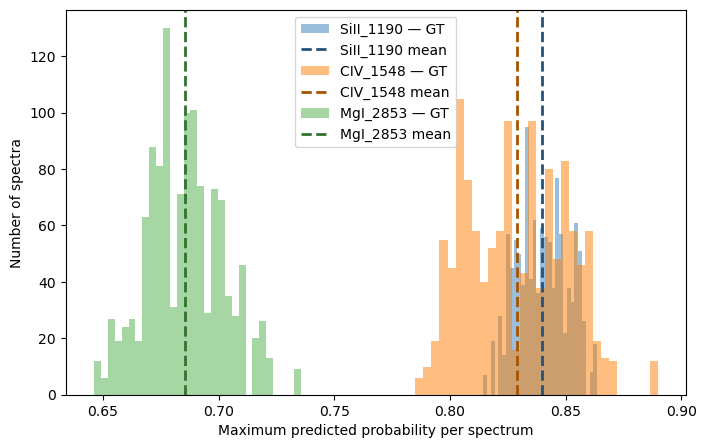

In [32]:
prob_threshes = evaluate_unet_stats(
    model=model,
    val_loader=val_loader,
    device=device,
    metal_names=species_names,
)

In [33]:
prob_threshes

[0.83984625, 0.8289702, 0.68530005]


 MOCK EVALUATION: SiII_1190
Total spectra:        2000
GT-positive spectra:  1146
GT-negative spectra:  854

-----------------------------------------------------------------
POINT-LEVEL CLASSIFICATION (p >= 0.50)
-----------------------------------------------------------------
True Positives:        1210772
False Positives:        869075
False Negatives:         61019
True Negatives:       59861134
Purity:               0.5821
Completeness:         0.9520

-----------------------------------------------------------------
SPECTRUM-LEVEL CLASSIFICATION (p >= 0.50)
Minimum contiguous points: 3
-----------------------------------------------------------------
True Positives:           1146
False Positives:           854
False Negatives:             0
True Negatives:              0
Purity:               0.5730
Completeness:         1.0000

-----------------------------------------------------------------
SPECTRUM-LEVEL AMPLITUDE RECOVERY
--------------------------------------------------

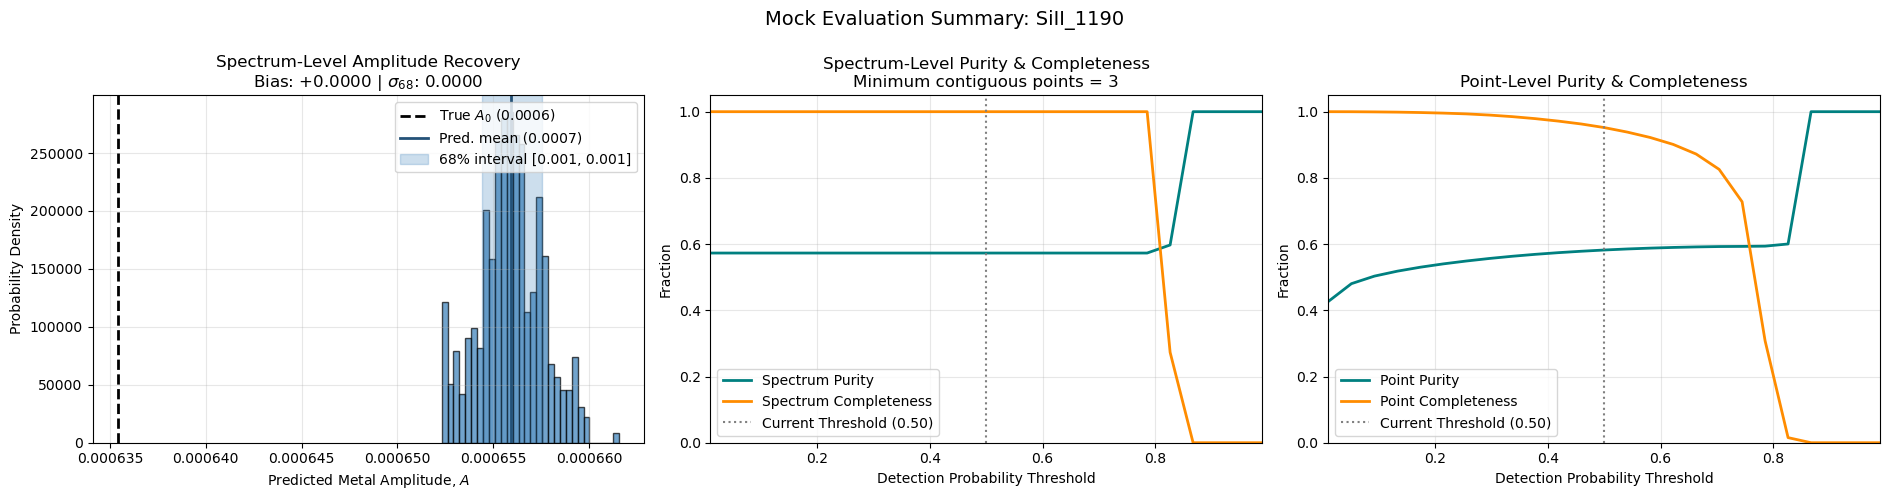


 MOCK EVALUATION: CIV_1548
Total spectra:        2000
GT-positive spectra:  1244
GT-negative spectra:  756

-----------------------------------------------------------------
POINT-LEVEL CLASSIFICATION (p >= 0.50)
-----------------------------------------------------------------
True Positives:        1345357
False Positives:        765129
False Negatives:         95242
True Negatives:       59796272
Purity:               0.6375
Completeness:         0.9339

-----------------------------------------------------------------
SPECTRUM-LEVEL CLASSIFICATION (p >= 0.50)
Minimum contiguous points: 3
-----------------------------------------------------------------
True Positives:           1244
False Positives:           756
False Negatives:             0
True Negatives:              0
Purity:               0.6220
Completeness:         1.0000

-----------------------------------------------------------------
SPECTRUM-LEVEL AMPLITUDE RECOVERY
---------------------------------------------------

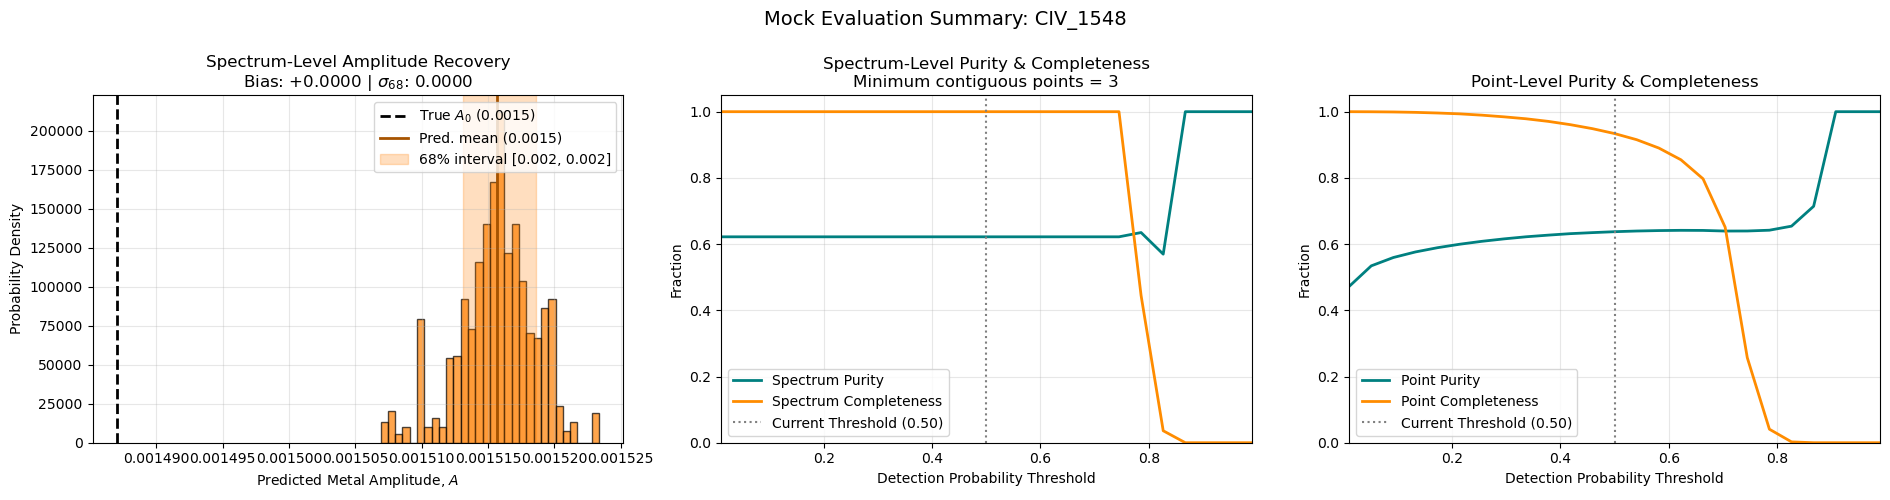


 MOCK EVALUATION: MgI_2853
Total spectra:        2000
GT-positive spectra:  1221
GT-negative spectra:  779

-----------------------------------------------------------------
POINT-LEVEL CLASSIFICATION (p >= 0.50)
-----------------------------------------------------------------
True Positives:        1107289
False Positives:        683652
False Negatives:        274972
True Negatives:       59936087
Purity:               0.6183
Completeness:         0.8011

-----------------------------------------------------------------
SPECTRUM-LEVEL CLASSIFICATION (p >= 0.50)
Minimum contiguous points: 3
-----------------------------------------------------------------
True Positives:           1221
False Positives:           779
False Negatives:             0
True Negatives:              0
Purity:               0.6105
Completeness:         1.0000

-----------------------------------------------------------------
SPECTRUM-LEVEL AMPLITUDE RECOVERY
---------------------------------------------------

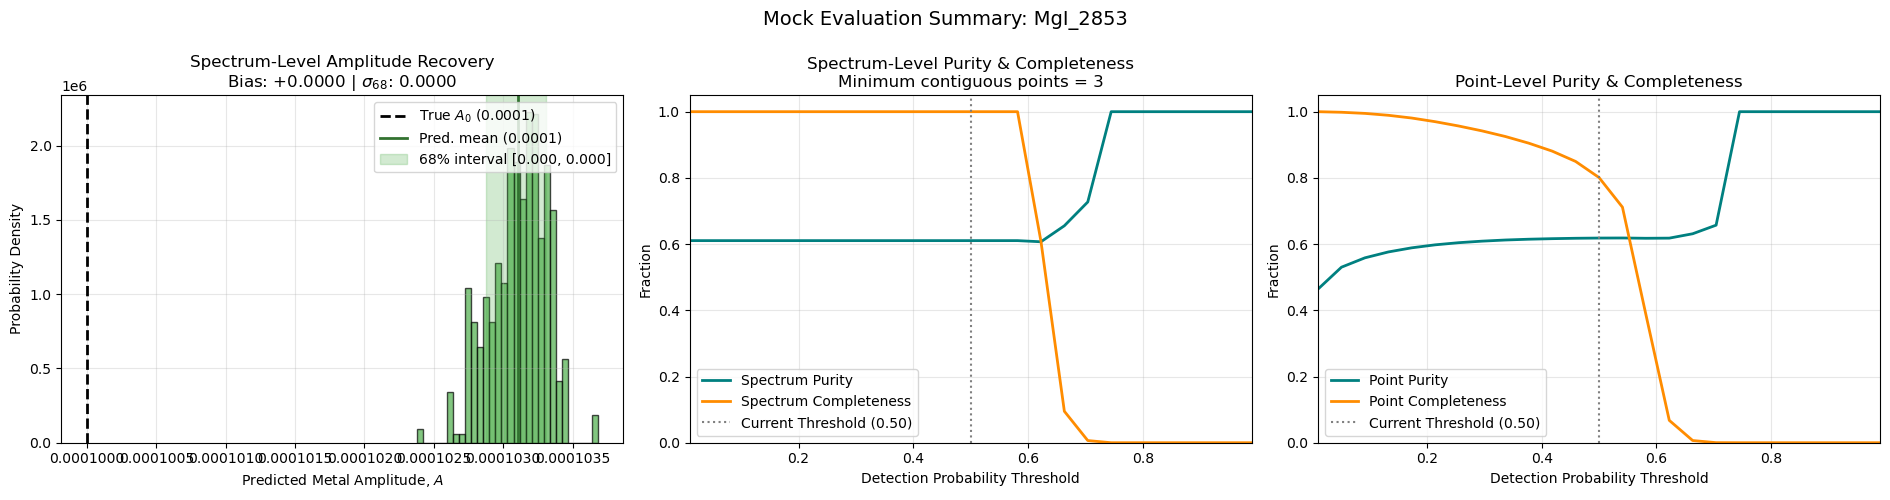

In [34]:
# Evaluate the validation dataset
evaluate_unet_mock_performance(
    model=model,
    val_loader=val_loader,
    device=device,
    metal_names=species_names,
    # prob_thresh= [0.8, 0.7, 0.7],
    prob_thresh= 0.5,
    min_contiguous_points=3,
    plot=True,
    print_stats=True,
)


 PREDICTION SUMMARY: SiII_1190
 Probability threshold: 0.500
 Minimum contiguous points: 3
 Spectra evaluated: 2000
 Spectra with ≥1 detection: 2000
 Detection fraction: 1.0000
 Total detected regions: 213569
 Max probability (mean / 16-84%): 0.805 / 0.793-0.823
 Mean predicted amplitude (mean / 16-84%): 0.00066 / 0.00064-0.00067
 Detection-region size (mean / 16-84%): 9.4 / 4.0-15.0 points
 True amplitude: 0.00064
 Amplitude RMSE (mean prediction vs. true): 0.00002

 PREDICTION SUMMARY: CIV_1548
 Probability threshold: 0.500
 Minimum contiguous points: 3
 Spectra evaluated: 2000
 Spectra with ≥1 detection: 2000
 Detection fraction: 1.0000
 Total detected regions: 220605
 Max probability (mean / 16-84%): 0.769 / 0.746-0.797
 Mean predicted amplitude (mean / 16-84%): 0.00152 / 0.00149-0.00155
 Detection-region size (mean / 16-84%): 9.3 / 4.0-15.0 points
 True amplitude: 0.00149
 Amplitude RMSE (mean prediction vs. true): 0.00003

 PREDICTION SUMMARY: MgI_2853
 Probability threshold: 0.

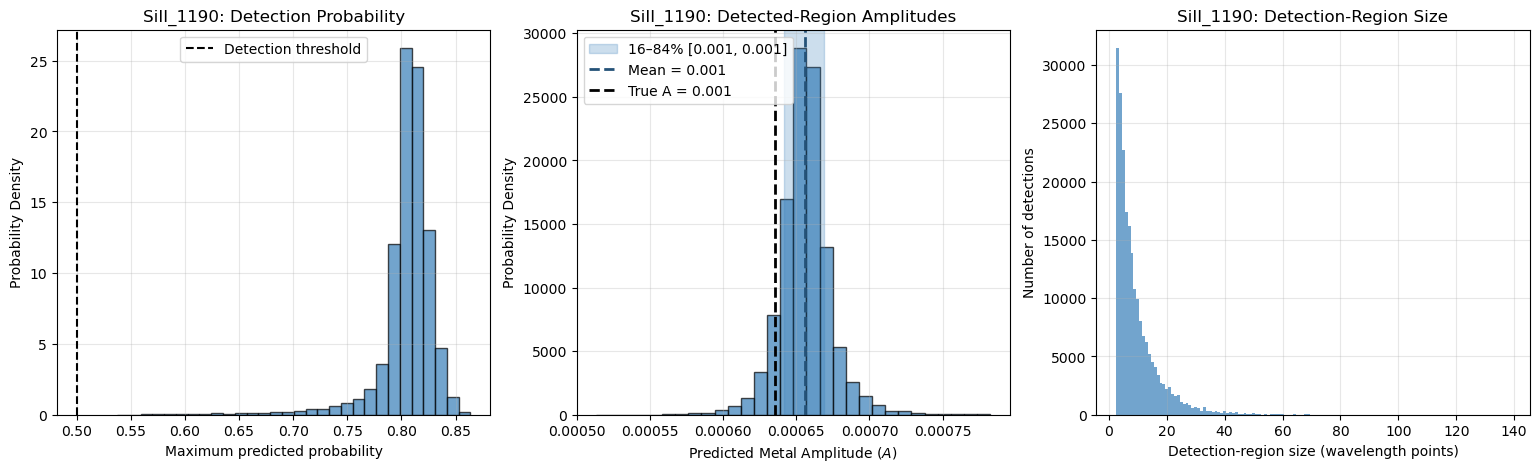

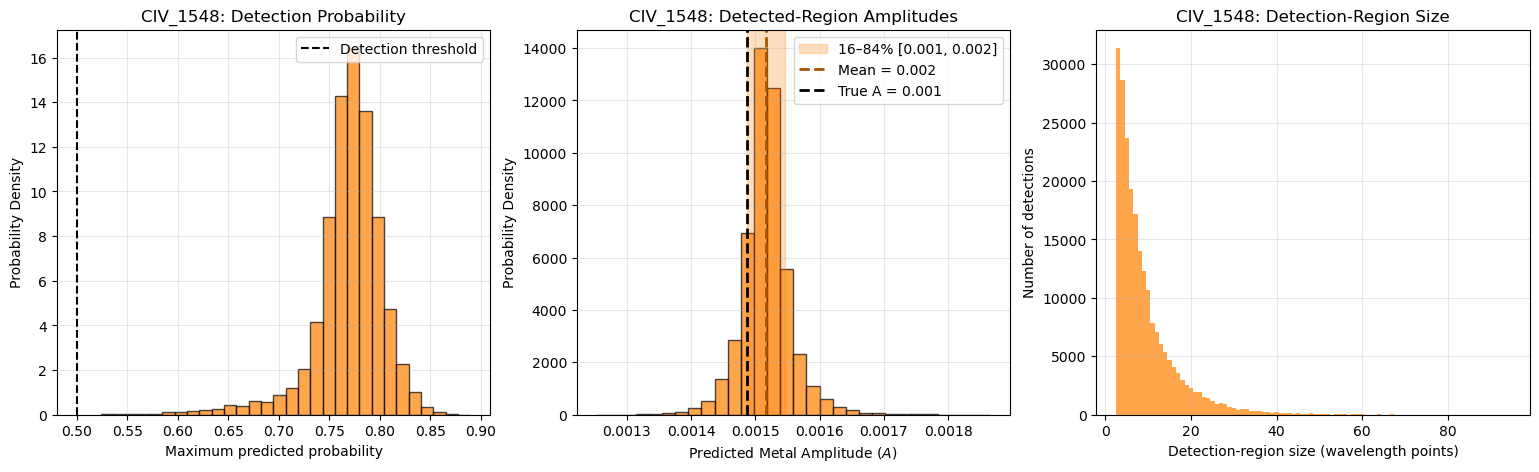

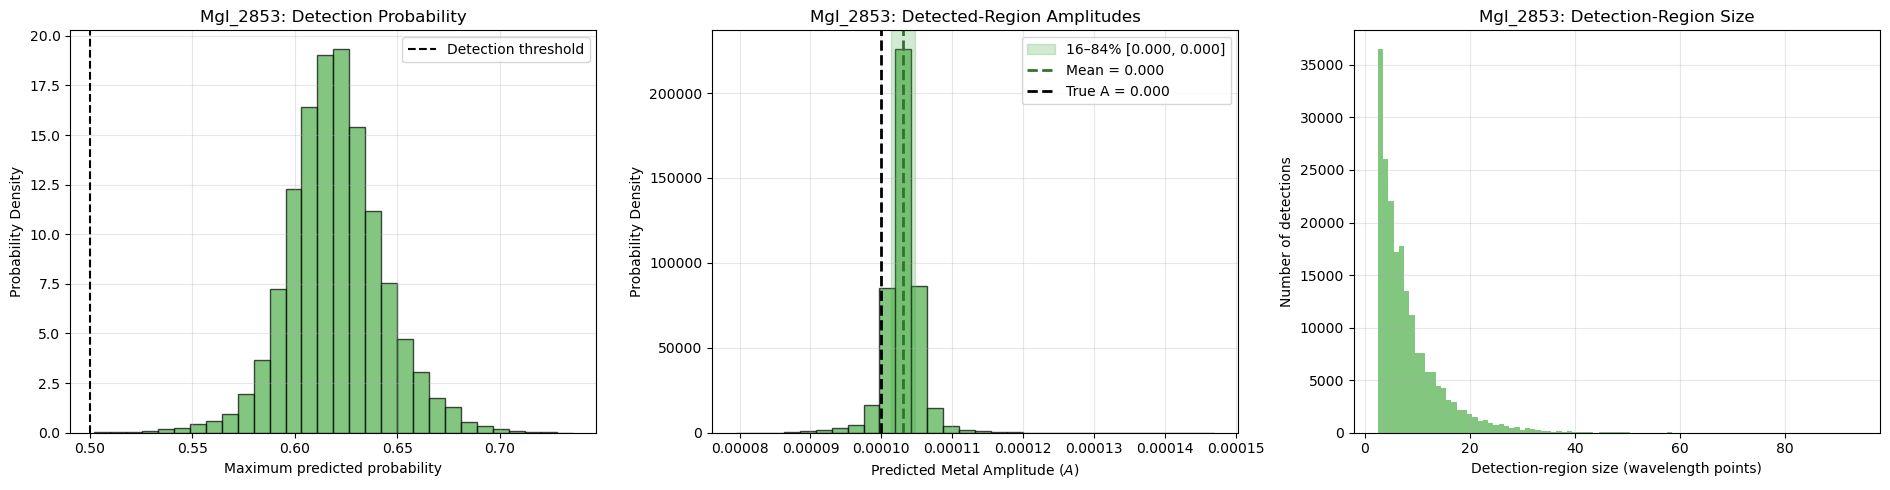

In [35]:
# evaluate as if real data w/o a ground truth 
detection_catalog, species_stats = evaluate_unet_predictions(
    model=model,
    data_loader=val_loader,
    device=device,
    metal_names=species_names,
    # log_wave_grid= None,
    # prob_thresh= [0.8, 0.7, 0.7],
    prob_thresh= 0.5,
    min_contiguous_points=3,
    plot=True,
    print_stats=True,
    a_true=a_target,
)



In [74]:
# detection_catalog[0] # species_stats

In [38]:
# Test on separate external dataset (pt 1)

log_wave, fluxes_log = rebin_dataset_to_log_lambda(wave, fluxes)

# 1. Configuration
metal_dict = {'SiII_1190': 1190.4158, 'CIV_1548': 1548.2049, 'MgI_2853': 2852.96}
a_target = [0.002, 0.005, 0.001]
tau_core_cutoff = 1.0
tau_min_thresh = [a * tau_core_cutoff for a in a_target] 

test_dataset = generate_multimetal_dataset(
    lya_flux_samples=fluxes_log,
    log_wave_grid=log_wave,
    metal_dict=metal_dict,
    a_min=a_target, 
    a_max=a_target,
    num_samples=1000,
    max_metals_per_spectrum=3,
    snr=None,
    tau_min_thresh=tau_min_thresh,
    zero_metal_prob=0.0,
)

test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False)

species_names = list(metal_dict.keys())
species_names

['SiII_1190', 'CIV_1548', 'MgI_2853']

In [40]:
# Test on separate external dataset (pt 2)
# 2. Run diagnostics directly
evaluate_fixed_amplitude_unet(
    model=model,
    val_loader=test_loader,
    device=device,
    metal_names=species_names,
    prob_thresh= [0.8, 0.75, 0.70],
    min_contiguous_pixels=3,
    plot=True
)


 FIXED AMPLITUDE METRICS: SiII_1190 (True A0 = 0.0020)
 SPECTRUM-LEVEL CLASSIFICATION (p >= 0.80, Spatial Match & Min Contig = 3 px):
   True Positives:   653 | False Positives:  347
   False Negatives:    0 | True Negatives:     0
   Purity (Precision):    0.6530
   Completeness (Recall): 1.0000
------------------------------------------------------------
 SPECTRUM-LEVEL AMPLITUDE RECOVERY (Linear Units A):
   Detected Spectra (TPs):    653 / 653
   Predicted Amplitude Median: 0.0021
   Global Bias (Pred - True):  +0.0001
   68% Spread (sigma_68):     0.0000
   Spectrum Amplitude MAE:     0.0001

 FIXED AMPLITUDE METRICS: CIV_1548 (True A0 = 0.0050)
 SPECTRUM-LEVEL CLASSIFICATION (p >= 0.75, Spatial Match & Min Contig = 3 px):
   True Positives:   648 | False Positives:  352
   False Negatives:    0 | True Negatives:     0
   Purity (Precision):    0.6480
   Completeness (Recall): 1.0000
------------------------------------------------------------
 SPECTRUM-LEVEL AMPLITUDE RECOVERY (

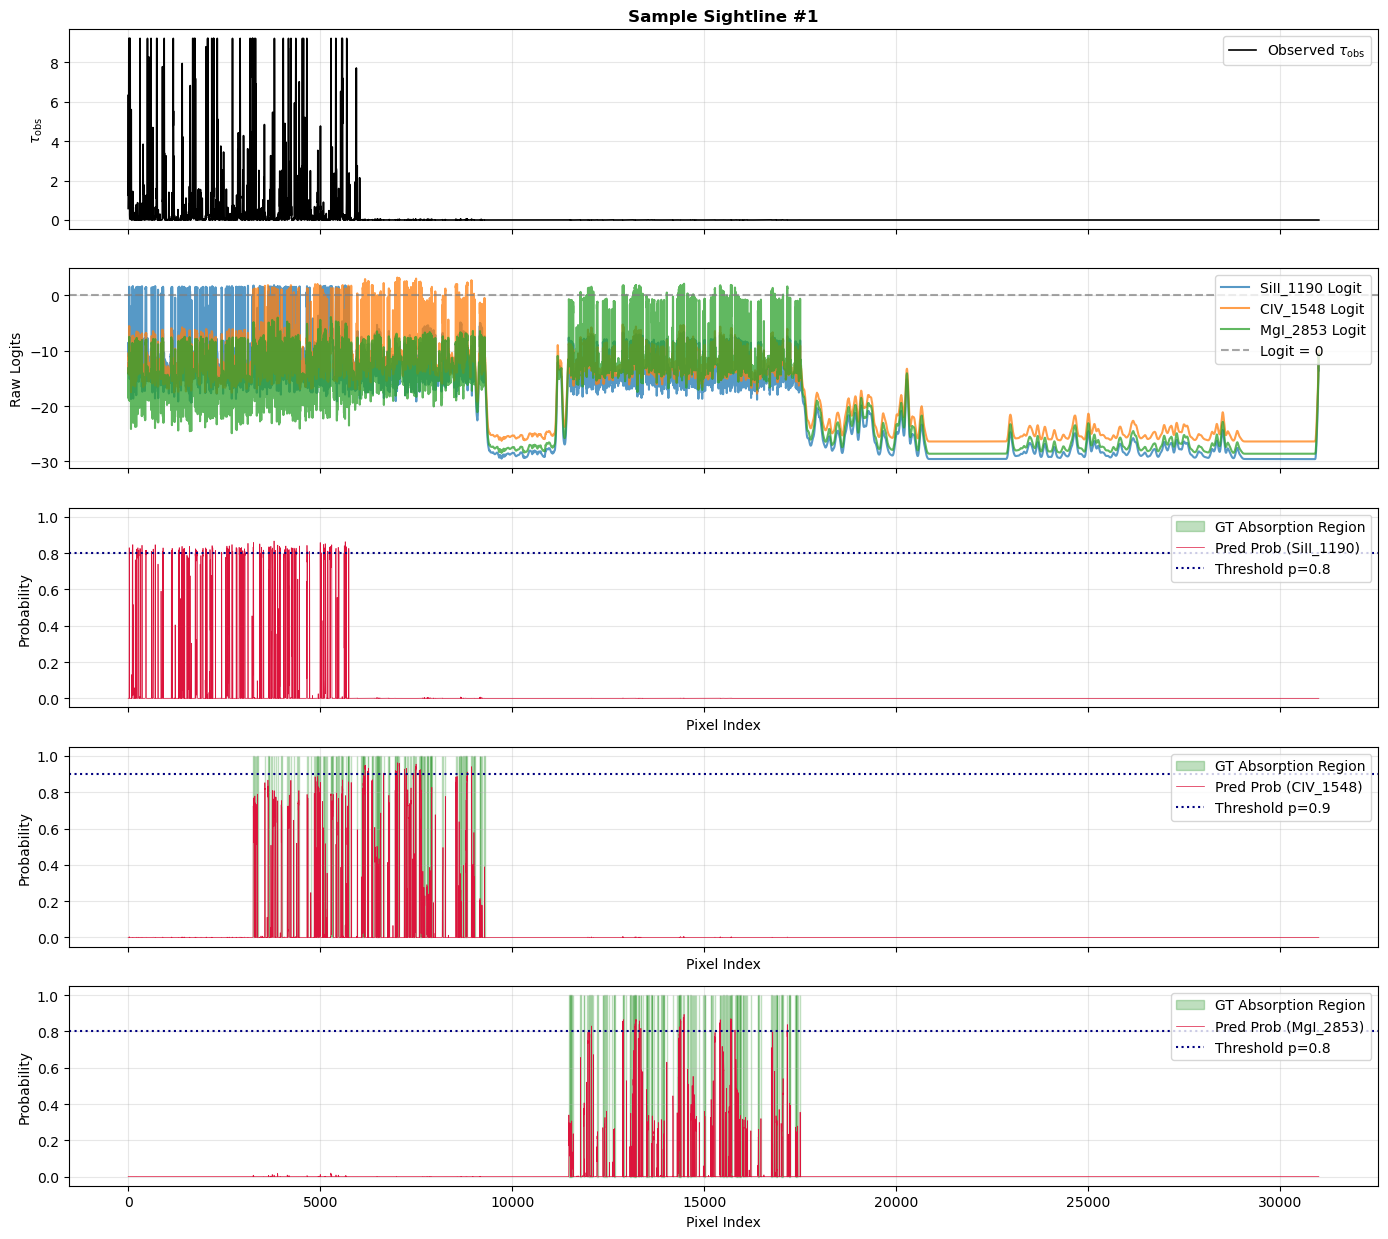

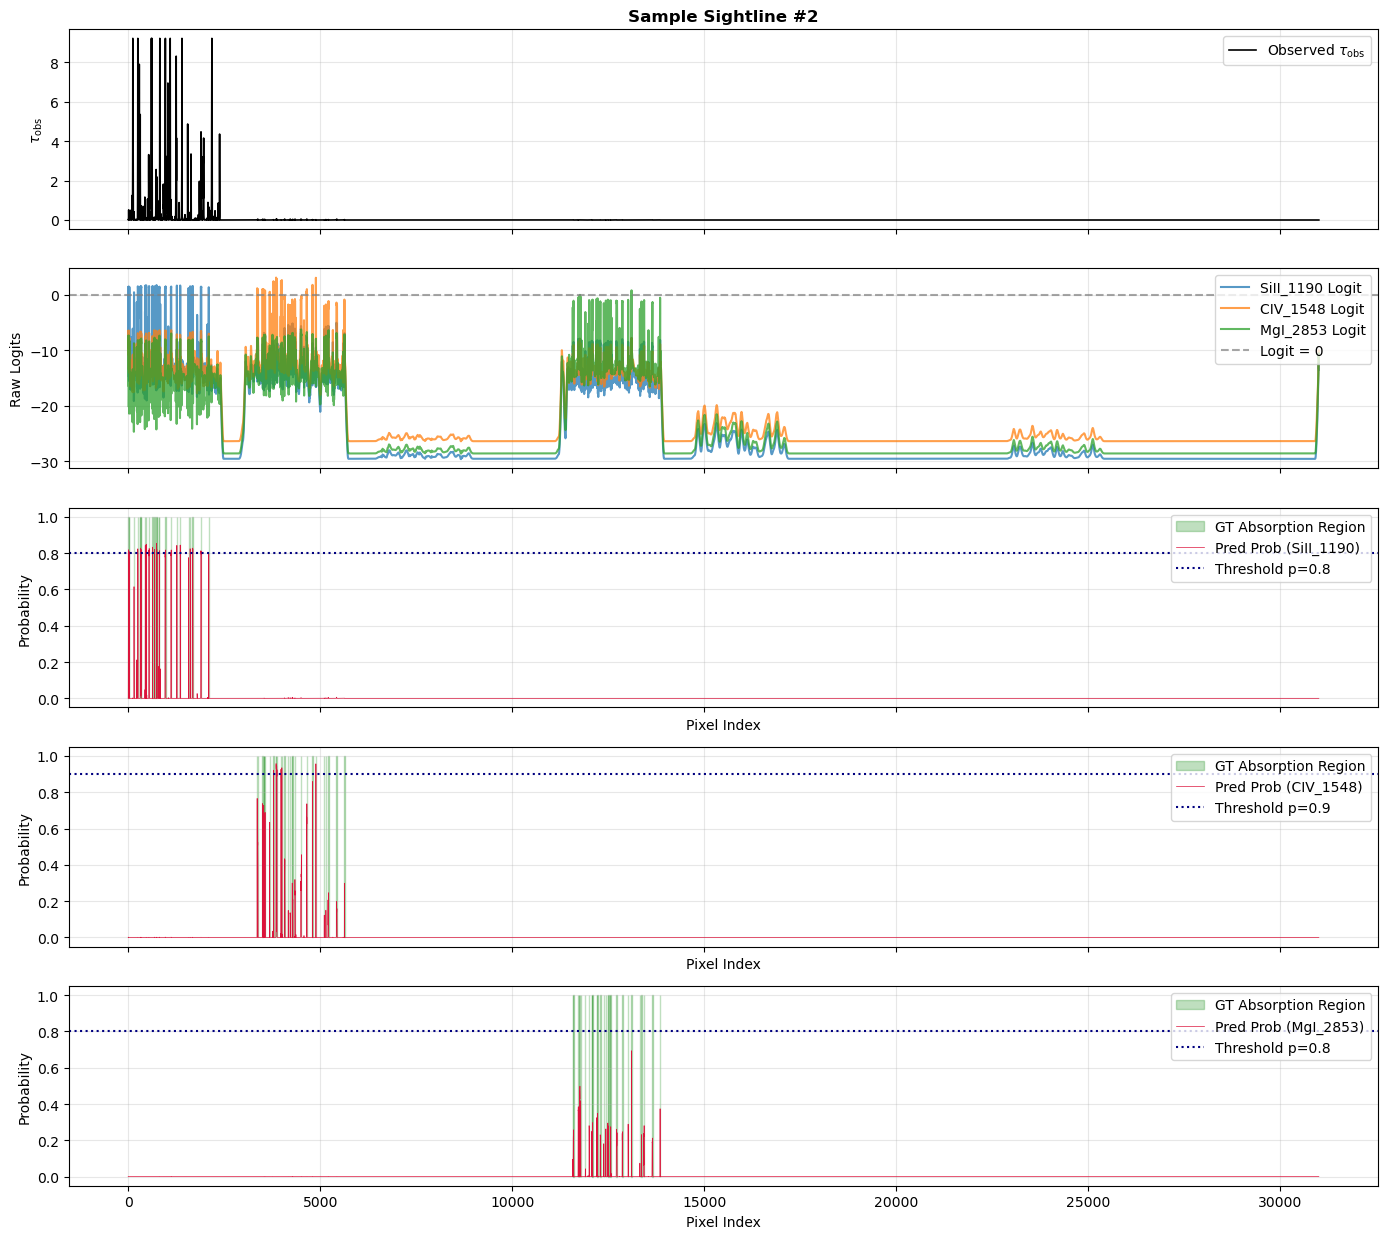

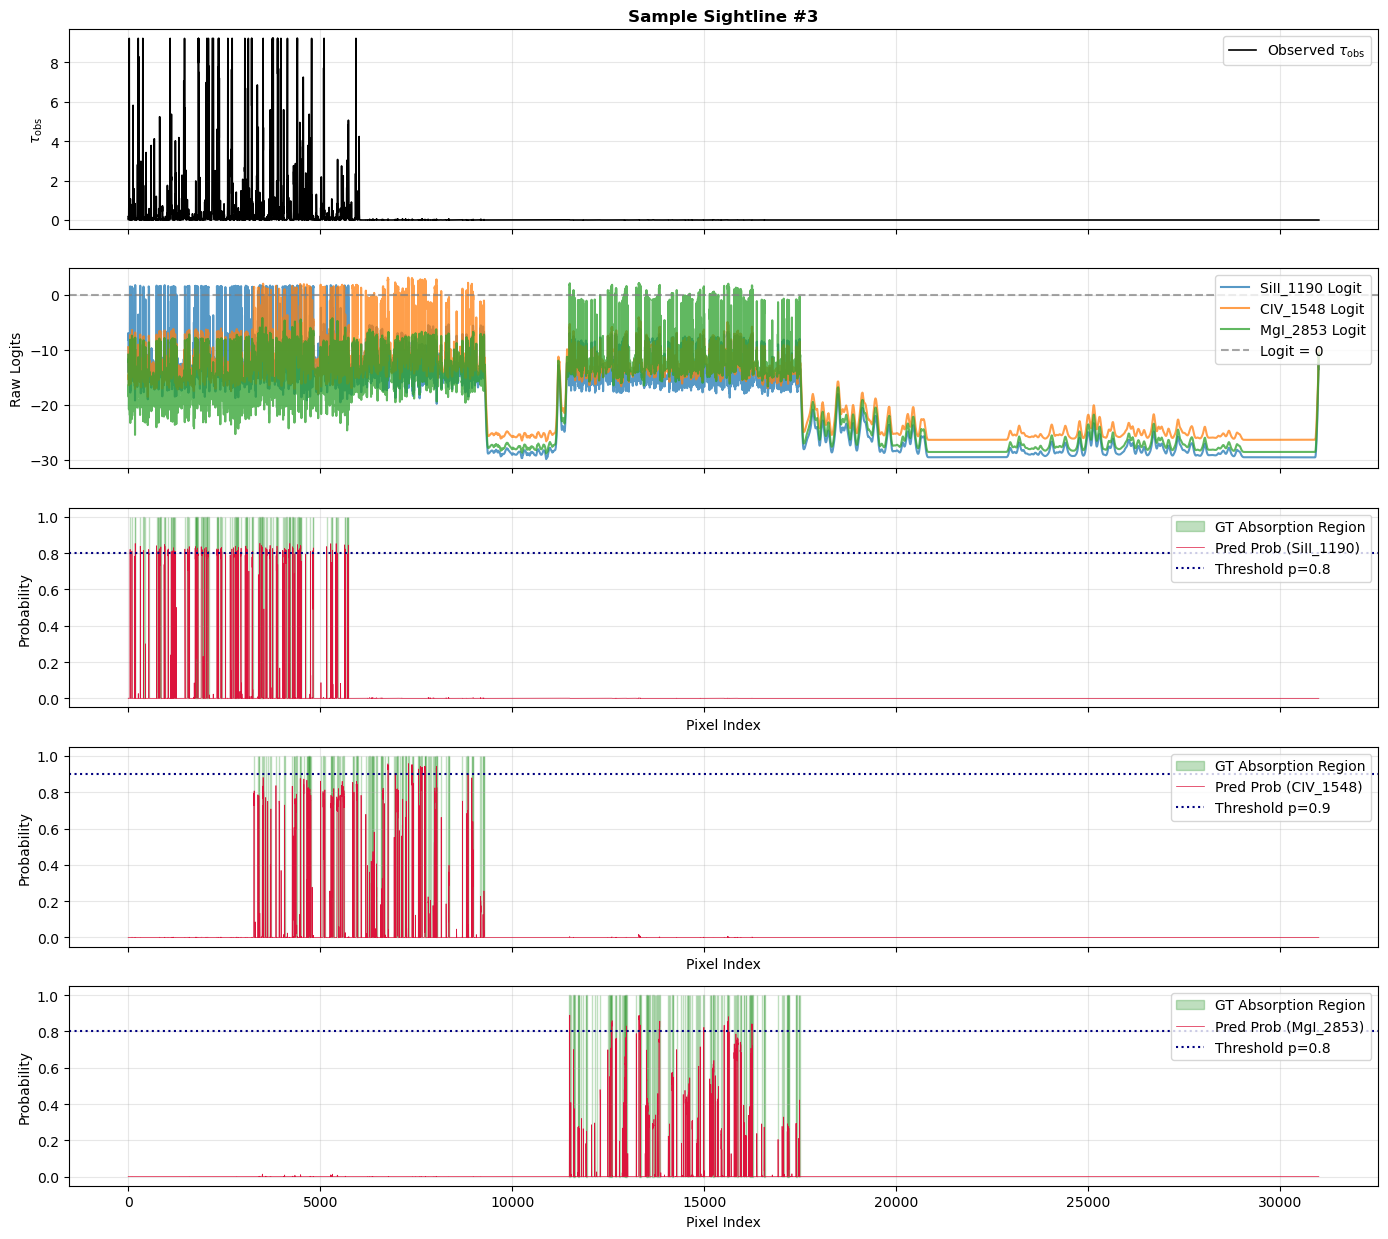

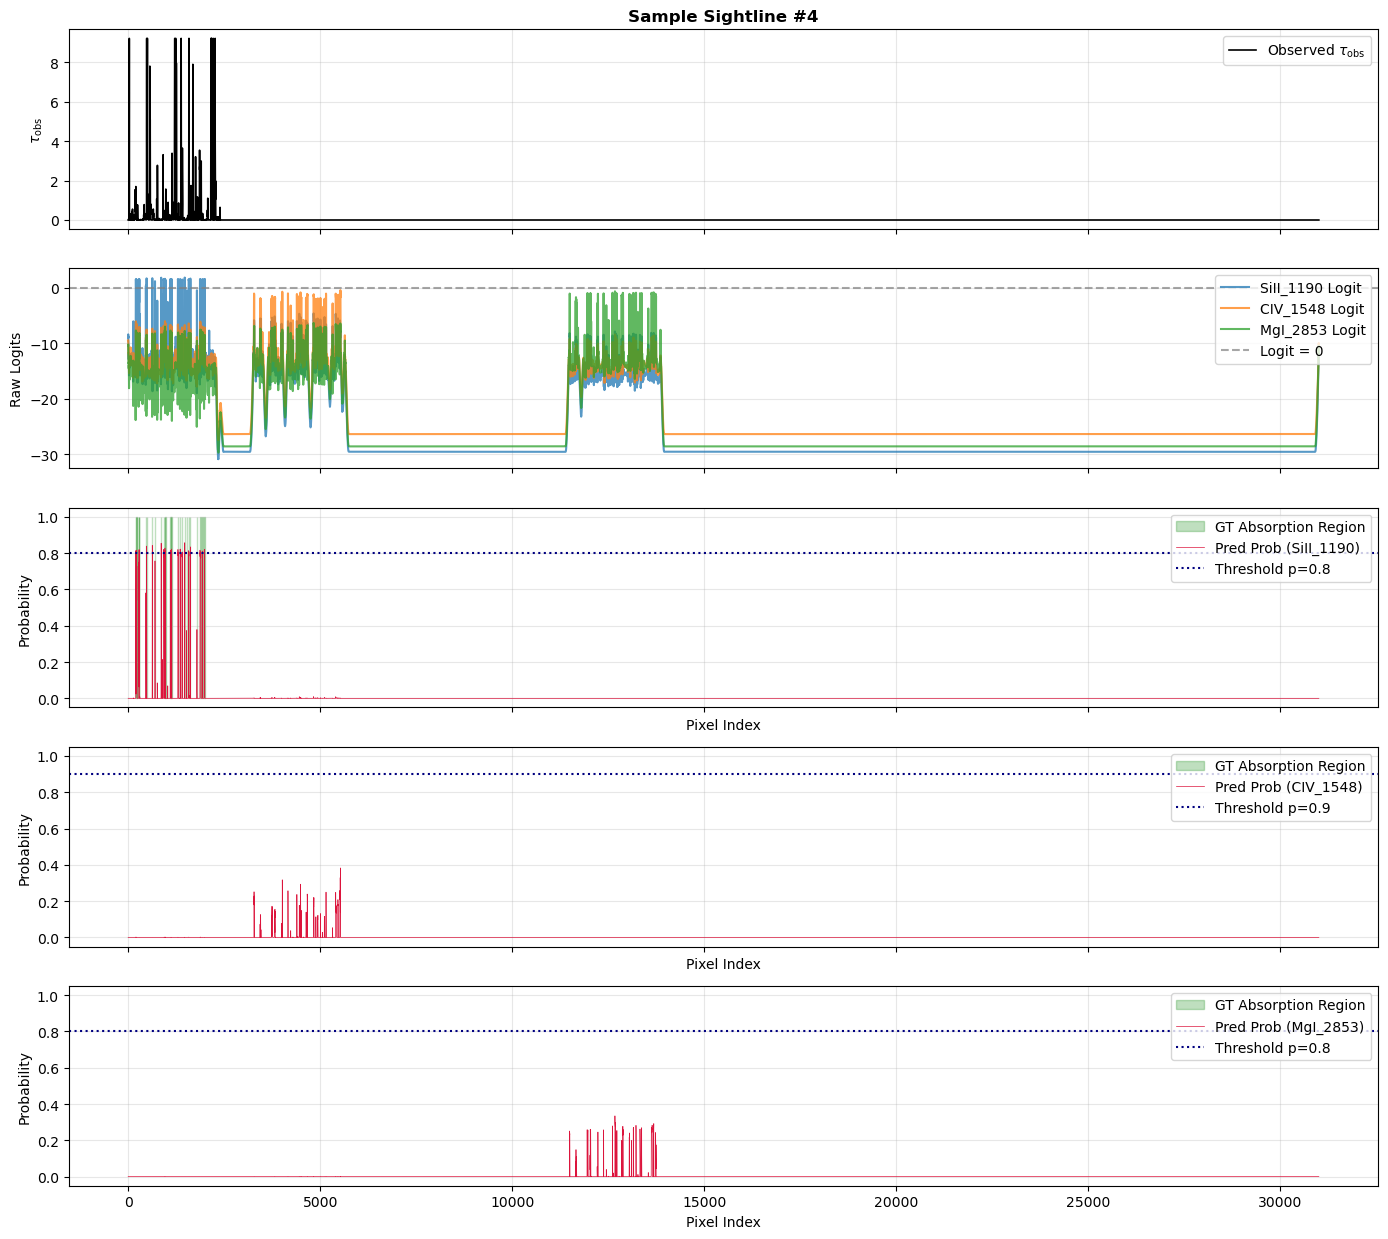


KeyboardInterrupt



In [33]:
plot_sample_predictions(
    model=model, 
    val_loader=val_loader, 
    device=device, 
    metal_dict=metal_dict, 
    num_samples=10,
    prob_threshold= [0.8, 0.9, 0.8],
    # prob_threshold = 0.9,
)

# [0.9065548, 0.8716533, 0.80759895]
